
# FORTIFY leakage plots by topological level

This notebook reads `parents.txt` and `all_signal_leakage.csv`, builds a NetworkX graph, assigns each node a topological level using `nx.topological_generations`, and plots leakage values against topological level.

It also extracts fanin cones of high-leakage output signals and overlays those cone edges on the full leakage plot.


In [11]:

# -----------------------------
# User configuration
# -----------------------------
from pathlib import Path

PROJECT_ROOT = Path("fortify")
BENCHMARKS_DIR = PROJECT_ROOT / "Benchmarks"
RESULTS_ROOT = PROJECT_ROOT / "results"
RUN_NAME = "aes"               # e.g. "demo", "aes", "2026-..."
OUTPUT_ROOT = PROJECT_ROOT / "analysis_outputs" / "leakage_topology"

AES_SIZES = [100, 200, 700, 800, 1100, 1200, 1600, 1700]
# For quick testing, uncomment the next line.
# AES_SIZES = [100, 200]
DESIGN_NAME_TEMPLATE = "aes{size}"       # produces aes100
RESULT_SUBDIR_TEMPLATE = "{design}_recon"      # use "{design}_recon" if your folders are aes100_recon
VERILOG_FILE_TEMPLATE = "AES{size}.v"

PARENTS_FILENAME = "parents.txt"
LEAKAGE_FILENAME = "all_signal_leakage.csv"

# High-leakage output selection.
LEAKAGE_THRESHOLD = 1e-8
TARGET_OUTPUT_PREFIXES = ["top.Capacitance", "top.out"]
# Set to None to allow any signal above the threshold.
# TARGET_OUTPUT_PREFIXES = None

# Maximum number of above-threshold target signals per design for which fanin lines are drawn.
# Set to None to use all targets above the threshold.
MAX_TARGETS_PER_DESIGN = 5

# Drawing controls.
MAX_FANIN_EDGES_DRAWN_PER_DESIGN = 50000
SHOW_PLOTS_IN_NOTEBOOK = True
SAVE_PLOTS = True
SAVE_CSVS = True
X_JITTER = 0.0   # keep 0.0 if you want exact integer topological levels on x-axis

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

DESIGN_SPECS = []
for size in AES_SIZES:
    design = DESIGN_NAME_TEMPLATE.format(size=size)
    DESIGN_SPECS.append({
        "size": size,
        "design": design,
        "verilog_path": BENCHMARKS_DIR / VERILOG_FILE_TEMPLATE.format(size=size),
        "result_dir": RESULTS_ROOT / RUN_NAME / RESULT_SUBDIR_TEMPLATE.format(design=design, size=size),
    })

DESIGN_SPECS[:2]

DESIGN_COLORS = [
    "#e41a1c",  # red
    "#377eb8",  # blue
    "#4daf4a",  # green
    "#984ea3",  # purple
    "#ff7f00",  # orange
    "#ffff33",  # yellow
    "#a65628",  # brown
    "#f781bf",  # pink
    "#999999",  # gray
    "#17becf",  # cyan
]

FANIN_LINE_WIDTH = 1.6
FANIN_LINE_ALPHA = 0.65


# -----------------------------
# Trojan-output candidate mining controls
# -----------------------------
# This later section scores output-like nodes without using a fixed leakage threshold.
# Use "prefix" when you know the suspicious/top-level output prefixes.
# Use "sinks" when you want all graph sink nodes with leakage.
# Use "prefix_or_sinks" to be broad.
TROJAN_OUTPUT_NODE_MODE = "prefix_or_sinks"          # "prefix", "sinks", or "prefix_or_sinks"
TROJAN_OUTPUT_PREFIXES = TARGET_OUTPUT_PREFIXES

# Exclude signals that are technically module input pins, such as:
#   top.AES.a1.S4_0.u0.in
#   top.AES.a1.S4_0.u0.in[3]
#   top.AES.a1.S4_0.u0.in[3:3]
#   top.AES.a1.S4_0.u0.in[7:0]
EXCLUDE_INPUT_LIKE_CANDIDATES = True

# None means score every candidate output-like node. If it is slow, set 200 or 500.
TROJAN_MAX_OUTPUT_CANDIDATES_TO_SCORE = 200
TROJAN_TOP_REPORT_N = 100
TROJAN_MIN_FANIN_LEAKAGE_NODES = 5
TROJAN_NEAR_TARGET_DISTANCE = 3

# For saved bar plots of the highest ranked candidate outputs.
TROJAN_BAR_PLOT_TOP_N = 40

# Small value to avoid divide-by-zero in lift ratios.
LEAKAGE_EPS = 1e-30


In [12]:

# -----------------------------
# Imports
# -----------------------------
import ast
import math
import pickle
import re
from collections import deque

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from IPython.display import display

pd.set_option("display.max_colwidth", 160)


In [13]:

# -----------------------------
# Parsers and graph utilities
# -----------------------------

def read_parents_txt(path):
    """
    Parse parents.txt lines of the form:
        child_node: ['parent0', 'parent1', ...]

    Signal names contain colons inside bit slices, so the split is done using a
    greedy regex-like rule: the right side must be a Python list at the end.
    """
    path = Path(path)
    parents = {}

    with path.open("r", encoding="utf-8", errors="replace") as f:
        for raw in f:
            line = raw.strip()
            if not line or line.startswith("#"):
                continue

            if ":" not in line:
                continue

            # RHS is the last list-looking part. This avoids breaking on [7:0].
            lhs, sep, rhs = line.rpartition(":")
            if not sep:
                continue

            # If rpartition split inside [x:y], walk left until RHS parses as a list.
            candidate = None
            cur_lhs, cur_rhs = lhs, rhs
            while True:
                try:
                    val = ast.literal_eval(cur_rhs.strip())
                    if isinstance(val, list):
                        candidate = (cur_lhs.strip(), val)
                        break
                except Exception:
                    pass

                pos = cur_lhs.rfind(":")
                if pos < 0:
                    break
                cur_rhs = cur_lhs[pos + 1:] + ":" + cur_rhs
                cur_lhs = cur_lhs[:pos]

            if candidate is None:
                continue

            child, plist = candidate
            clean_parents = []
            for p in plist:
                if isinstance(p, str) and p:
                    clean_parents.append(p)
            parents[child] = clean_parents

    return parents


def build_networkx_graph_from_parents(parents, extra_nodes=None):
    """Build raw directed graph. Edges are parent -> child."""
    G = nx.DiGraph()

    for child, plist in parents.items():
        G.add_node(child)
        for parent in plist:
            G.add_node(parent)
            G.add_edge(parent, child)

    if extra_nodes:
        G.add_nodes_from(str(n) for n in extra_nodes if isinstance(n, str) and n)

    return G


def load_leakage_csv(path):
    """
    Returns:
        leakage_by_node[node] = {
            leakage, best_ref, actual_signal, actual_ref, pbv, prior
        }

    Supports the CSVs generated earlier:
        all_signal_leakage.csv
        all_signal_leakage_by_ref.csv
    """
    path = Path(path)
    df = pd.read_csv(path)

    # Normalize likely column names.
    colmap = {c.lower(): c for c in df.columns}
    signal_col = colmap.get("signal")
    ref_col = colmap.get("ref")
    actual_signal_col = colmap.get("actualsignal") or colmap.get("actual_signal")
    actual_ref_col = colmap.get("actualref") or colmap.get("actual_ref")
    leakage_col = colmap.get("leakage_pbv")
    pbv_col = colmap.get("pbv")
    prior_col = colmap.get("prior")

    if signal_col is None or leakage_col is None:
        raise ValueError(f"{path} must contain at least Signal and Leakage_PBV columns")

    df[leakage_col] = pd.to_numeric(df[leakage_col], errors="coerce").fillna(0.0)
    if pbv_col:
        df[pbv_col] = pd.to_numeric(df[pbv_col], errors="coerce")
    if prior_col:
        df[prior_col] = pd.to_numeric(df[prior_col], errors="coerce")

    leakage_by_node = {}

    def add_row(node_name, row):
        if not isinstance(node_name, str) or not node_name:
            return
        leakage = float(row[leakage_col])
        old = leakage_by_node.get(node_name)
        if old is not None and old["leakage"] >= leakage:
            return
        leakage_by_node[node_name] = {
            "leakage": leakage,
            "best_ref": str(row[ref_col]) if ref_col else "",
            "actual_signal": str(row[actual_signal_col]) if actual_signal_col else str(row[signal_col]),
            "actual_ref": str(row[actual_ref_col]) if actual_ref_col else (str(row[ref_col]) if ref_col else ""),
            "pbv": float(row[pbv_col]) if pbv_col and not pd.isna(row[pbv_col]) else math.nan,
            "prior": float(row[prior_col]) if prior_col and not pd.isna(row[prior_col]) else math.nan,
        }

    for _, row in df.iterrows():
        add_row(str(row[signal_col]), row)
        if actual_signal_col:
            add_row(str(row[actual_signal_col]), row)

    return leakage_by_node, df


def graph_levels_with_networkx(G):
    """
    Assign a topological level to each graph node.

    If G is already a DAG, levels come directly from nx.topological_generations(G).
    If G has cycles, SCCs are condensed using nx.condensation(G), which is a DAG,
    then nx.topological_generations is applied to that condensation DAG.
    """
    if nx.is_directed_acyclic_graph(G):
        level_by_node = {}
        generation_by_level = []
        for level, nodes in enumerate(nx.topological_generations(G)):
            nodes = list(nodes)
            generation_by_level.append(nodes)
            for n in nodes:
                level_by_node[n] = level
        scc_size_by_node = {n: 1 for n in G.nodes}
        return level_by_node, scc_size_by_node, generation_by_level, G

    C = nx.condensation(G)
    comp_to_members = C.graph["mapping"]  # node -> component id
    members_by_comp = {}
    for n, comp in comp_to_members.items():
        members_by_comp.setdefault(comp, []).append(n)

    comp_level = {}
    generation_by_level = []
    for level, comps in enumerate(nx.topological_generations(C)):
        level_nodes = []
        for comp in comps:
            comp_level[comp] = level
            level_nodes.extend(members_by_comp.get(comp, []))
        generation_by_level.append(level_nodes)

    level_by_node = {n: comp_level[comp] for n, comp in comp_to_members.items()}
    scc_size_by_node = {n: len(members_by_comp[comp]) for n, comp in comp_to_members.items()}

    return level_by_node, scc_size_by_node, generation_by_level, C


def build_node_dataframe(G, leakage_by_node, design):
    level_by_node, scc_size_by_node, generations, level_dag = graph_levels_with_networkx(G)

    rows = []
    for n in G.nodes:
        leak = leakage_by_node.get(n)
        rows.append({
            "design": design,
            "node": n,
            "topological_level": int(level_by_node.get(n, -1)),
            "scc_size": int(scc_size_by_node.get(n, 1)),
            "indegree": int(G.in_degree(n)),
            "outdegree": int(G.out_degree(n)),
            "has_leakage": leak is not None,
            "leakage": leak["leakage"] if leak else math.nan,
            "plot_leakage": leak["leakage"] if leak else 0.0,
            "best_ref": leak["best_ref"] if leak else "",
            "actual_signal": leak["actual_signal"] if leak else "",
            "actual_ref": leak["actual_ref"] if leak else "",
            "pbv": leak["pbv"] if leak else math.nan,
            "prior": leak["prior"] if leak else math.nan,
        })

    df = pd.DataFrame(rows)
    df = df.sort_values(["topological_level", "node"]).reset_index(drop=True)
    return df, generations, level_dag


In [14]:

# -----------------------------
# Fanin cone utilities
# -----------------------------

def node_matches_prefix(node, prefixes):
    if prefixes is None:
        return True
    return any(str(node).startswith(prefix) for prefix in prefixes)


def select_high_leakage_targets(node_df, threshold, prefixes=None, max_targets=None):
    cand = node_df[
        (node_df["has_leakage"] == True)
        & (node_df["leakage"] > threshold)
        & (node_df["node"].map(lambda n: node_matches_prefix(n, prefixes)))
    ].copy()

    cand = cand.sort_values("leakage", ascending=False)
    if max_targets is not None:
        cand = cand.head(int(max_targets))

    return cand["node"].tolist(), cand


def transitive_fanin_cone(G, targets):
    """Use the raw graph, not the condensation DAG. Returns cone nodes and parent->child cone edges."""
    cone_nodes = set(targets)
    cone_edges = set()
    q = deque(targets)

    while q:
        child = q.popleft()
        for parent in G.predecessors(child):
            cone_edges.add((parent, child))
            if parent not in cone_nodes:
                cone_nodes.add(parent)
                q.append(parent)

    return cone_nodes, cone_edges


def add_plot_x(node_df, jitter=0.0):
    df = node_df.copy()
    df["x"] = df["topological_level"].astype(float)

    if jitter and jitter > 0:
        # Deterministic small jitter so repeated runs are stable.
        offsets = []
        for n in df["node"]:
            h = hash(n) % 10000
            offsets.append(((h / 9999.0) - 0.5) * float(jitter))
        df["x"] = df["x"] + offsets

    return df


def make_line_segments(plot_df, edges, max_edges=None):
    coord = {
        row.node: (float(row.x), float(row.plot_leakage))
        for row in plot_df.itertuples(index=False)
    }

    segments = []
    missing = 0
    for parent, child in sorted(edges):
        if parent not in coord or child not in coord:
            missing += 1
            continue
        segments.append([coord[parent], coord[child]])
        if max_edges is not None and len(segments) >= int(max_edges):
            break

    return segments, missing


In [15]:

# -----------------------------
# Plotting functions
# -----------------------------

def plot_fanin_only(bundle):
    design = bundle["design"]
    out_dir = bundle["out_dir"]
    node_df = bundle["node_df"]
    cone_nodes = bundle["cone_nodes"]
    cone_edges = bundle["cone_edges"]
    targets = bundle["targets"]

    cone_df = node_df[node_df["node"].isin(cone_nodes)].copy()
    cone_df = add_plot_x(cone_df, X_JITTER)

    fig, ax = plt.subplots(figsize=(15, 6))

    # Draw fanin edges first.
    segments, missing = make_line_segments(cone_df, cone_edges, MAX_FANIN_EDGES_DRAWN_PER_DESIGN)
    if segments:
        lc = LineCollection(segments, colors="black", linewidths=0.55, alpha=0.25, zorder=1)
        ax.add_collection(lc)

    # Draw all cone nodes.
    ax.scatter(
        cone_df["x"],
        cone_df["plot_leakage"],
        s=14,
        marker="o",
        alpha=0.75,
        linewidths=0,
        zorder=2,
    )

    # Highlight selected output targets.
    target_df = cone_df[cone_df["node"].isin(targets)]
    if not target_df.empty:
        ax.scatter(
            target_df["x"],
            target_df["plot_leakage"],
            s=90,
            marker="o",
            facecolors="none",
            edgecolors="black",
            linewidths=1.5,
            label="Selected high-leakage output",
            zorder=3,
        )

    ax.set_title(f"{design}: fanin cones of selected high-leakage outputs")
    ax.set_xlabel("Topological level")
    ax.set_ylabel("Leakage_PBV; missing leakage plotted at 0")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()

    path = out_dir / f"{design}_fanin_only.png"
    if SAVE_PLOTS:
        fig.savefig(path, dpi=220)
    if SHOW_PLOTS_IN_NOTEBOOK:
        display(fig)
    plt.close(fig)

    print(f"{design}: fanin-only drawable edges={len(segments)}, missing edges={missing}, saved={path}")
    return path


def plot_full_overlay(bundle):
    design = bundle["design"]
    out_dir = bundle["out_dir"]
    node_df = add_plot_x(bundle["node_df"], X_JITTER)
    cone_nodes = bundle["cone_nodes"]
    cone_edges = bundle["cone_edges"]
    targets = bundle["targets"]

    fig, ax = plt.subplots(figsize=(17, 6))

    # Background: all graph nodes.
    ax.scatter(
        node_df["x"],
        node_df["plot_leakage"],
        s=7,
        marker="o",
        alpha=0.18,
        linewidths=0,
        label="All nodes",
        zorder=1,
    )

    # Fanin edges.
    segments, missing = make_line_segments(node_df, cone_edges, MAX_FANIN_EDGES_DRAWN_PER_DESIGN)
    if segments:
        lc = LineCollection(segments, colors="black", linewidths=0.45, alpha=0.23, zorder=2)
        ax.add_collection(lc)

    # Fanin nodes.
    cone_df = node_df[node_df["node"].isin(cone_nodes)]
    ax.scatter(
        cone_df["x"],
        cone_df["plot_leakage"],
        s=14,
        marker="o",
        alpha=0.80,
        linewidths=0,
        label="Selected fanin cone nodes",
        zorder=3,
    )

    # Output targets.
    target_df = node_df[node_df["node"].isin(targets)]
    if not target_df.empty:
        ax.scatter(
            target_df["x"],
            target_df["plot_leakage"],
            s=90,
            marker="o",
            facecolors="none",
            edgecolors="black",
            linewidths=1.5,
            label="Selected high-leakage output",
            zorder=4,
        )

    ax.set_title(f"{design}: all nodes with selected high-leakage fanin cones overlaid")
    ax.set_xlabel("Topological level")
    ax.set_ylabel("Leakage_PBV; missing leakage plotted at 0")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()

    path = out_dir / f"{design}_full_overlay.png"
    if SAVE_PLOTS:
        fig.savefig(path, dpi=220)
    if SHOW_PLOTS_IN_NOTEBOOK:
        display(fig)
    plt.close(fig)

    print(f"{design}: full-overlay drawable edges={len(segments)}, missing edges={missing}, saved={path}")
    return path


def plot_combined_full_overlay(bundles):
    if not bundles:
        print("No designs to plot.")
        return None

    fig, ax = plt.subplots(figsize=(18, 7))
    design_to_color = {
        bundle["design"]: DESIGN_COLORS[idx % len(DESIGN_COLORS)]
        for idx, bundle in enumerate(bundles)
    }

    for idx, bundle in enumerate(bundles):
        design = bundle["design"]
        color = design_to_color[design]
        node_df = add_plot_x(bundle["node_df"], X_JITTER)
        cone_nodes = bundle["cone_nodes"]
        cone_edges = bundle["cone_edges"]
        targets = bundle["targets"]

        # Background points for this design.
        ax.scatter(
            node_df["x"],
            node_df["plot_leakage"],
            s=5,
            marker="o",
            alpha=0.08,
            linewidths=0,
            color=color,
            zorder=1,
        )

        # Fanin lines: different color per design.
        segments, missing = make_line_segments(node_df, cone_edges, MAX_FANIN_EDGES_DRAWN_PER_DESIGN)
        if segments:
            lc = LineCollection(
                segments,
                colors=[color],
                linewidths=FANIN_LINE_WIDTH,
                alpha=FANIN_LINE_ALPHA,
                zorder=2,
                label=design,
            )
            ax.add_collection(lc)

        # Fanin cone nodes.
        cone_df = node_df[node_df["node"].isin(cone_nodes)]
        ax.scatter(
            cone_df["x"],
            cone_df["plot_leakage"],
            s=10,
            marker="o",
            alpha=0.55,
            linewidths=0,
            color=color,
            zorder=3,
        )

        # Selected outputs.
        target_df = node_df[node_df["node"].isin(targets)]
        ax.scatter(
            target_df["x"],
            target_df["plot_leakage"],
            s=55,
            marker="o",
            facecolors="none",
            edgecolors=[color],
            linewidths=1.2,
            zorder=4,
        )

        print(f"combined {design}: targets={len(targets)}, cone_nodes={len(cone_nodes)}, drawn_edges={len(segments)}, missing_edges={missing}")

    ax.set_title("All designs: leakage by topological level with high-leakage fanin paths overlaid")
    ax.set_xlabel("Topological level")
    ax.set_ylabel("Leakage_PBV; missing leakage plotted at 0")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(frameon=False, title="Fanin-line design")
    fig.tight_layout()

    path = OUTPUT_ROOT / "combined_full_overlay_by_design.png"
    if SAVE_PLOTS:
        fig.savefig(path, dpi=240)
    if SHOW_PLOTS_IN_NOTEBOOK:
        display(fig)
    plt.close(fig)

    print(f"Saved combined plot to: {path}")
    return path


In [16]:

# -----------------------------
# Per-design analysis
# -----------------------------

def analyze_design(spec):
    design = spec["design"]
    result_dir = Path(spec["result_dir"])
    parents_path = result_dir / PARENTS_FILENAME
    leakage_path = result_dir / LEAKAGE_FILENAME
    out_dir = OUTPUT_ROOT / design
    out_dir.mkdir(parents=True, exist_ok=True)

    if not parents_path.exists():
        raise FileNotFoundError(f"Missing parents file: {parents_path}")
    if not leakage_path.exists():
        raise FileNotFoundError(f"Missing leakage CSV: {leakage_path}")

    print()
    print(f"=== {design} ===")
    print(f"parents: {parents_path}")
    print(f"leakage: {leakage_path}")

    parents = read_parents_txt(parents_path)
    leakage_by_node, leakage_raw_df = load_leakage_csv(leakage_path)
    G = build_networkx_graph_from_parents(parents, extra_nodes=list(leakage_by_node.keys()))
    node_df, generations, level_dag = build_node_dataframe(G, leakage_by_node, design)

    targets, target_df = select_high_leakage_targets(
        node_df,
        threshold=LEAKAGE_THRESHOLD,
        prefixes=TARGET_OUTPUT_PREFIXES,
        max_targets=MAX_TARGETS_PER_DESIGN,
    )

    cone_nodes, cone_edges = transitive_fanin_cone(G, targets)

    print(f"nodes={G.number_of_nodes()}, edges={G.number_of_edges()}, DAG={nx.is_directed_acyclic_graph(G)}")
    print(f"topological levels={node_df['topological_level'].max() + 1 if len(node_df) else 0}")
    print(f"leakage nodes={int(node_df['has_leakage'].sum())}")
    print(f"selected targets={len(targets)}, cone_nodes={len(cone_nodes)}, cone_edges={len(cone_edges)}")

    if SAVE_CSVS:
        node_df.to_csv(out_dir / f"{design}_nodes_levels_leakage.csv", index=False)
        target_df.to_csv(out_dir / f"{design}_selected_targets.csv", index=False)
        pd.DataFrame({"node": sorted(cone_nodes)}).to_csv(out_dir / f"{design}_fanin_nodes.csv", index=False)
        pd.DataFrame(sorted(cone_edges), columns=["parent", "child"]).to_csv(out_dir / f"{design}_fanin_edges.csv", index=False)
        nx.write_edgelist(G, out_dir / f"{design}_raw_graph_edges.txt", data=False)
        with open(out_dir / f"{design}_graph.pkl", "wb") as f:
            pickle.dump(G, f)

    bundle = {
        "design": design,
        "spec": spec,
        "out_dir": out_dir,
        "parents_path": parents_path,
        "leakage_path": leakage_path,
        "graph": G,
        "node_df": node_df,
        "generations": generations,
        "level_dag": level_dag,
        "targets": targets,
        "target_df": target_df,
        "cone_nodes": cone_nodes,
        "cone_edges": cone_edges,
    }

    plot_fanin_only(bundle)
    plot_full_overlay(bundle)

    return bundle


=== aes100 ===
parents: fortify/results/aes/aes100_recon/parents.txt
leakage: fortify/results/aes/aes100_recon/all_signal_leakage.csv
nodes=80626, edges=98310, DAG=False
topological levels=122
leakage nodes=76298
selected targets=5, cone_nodes=61, cone_edges=111


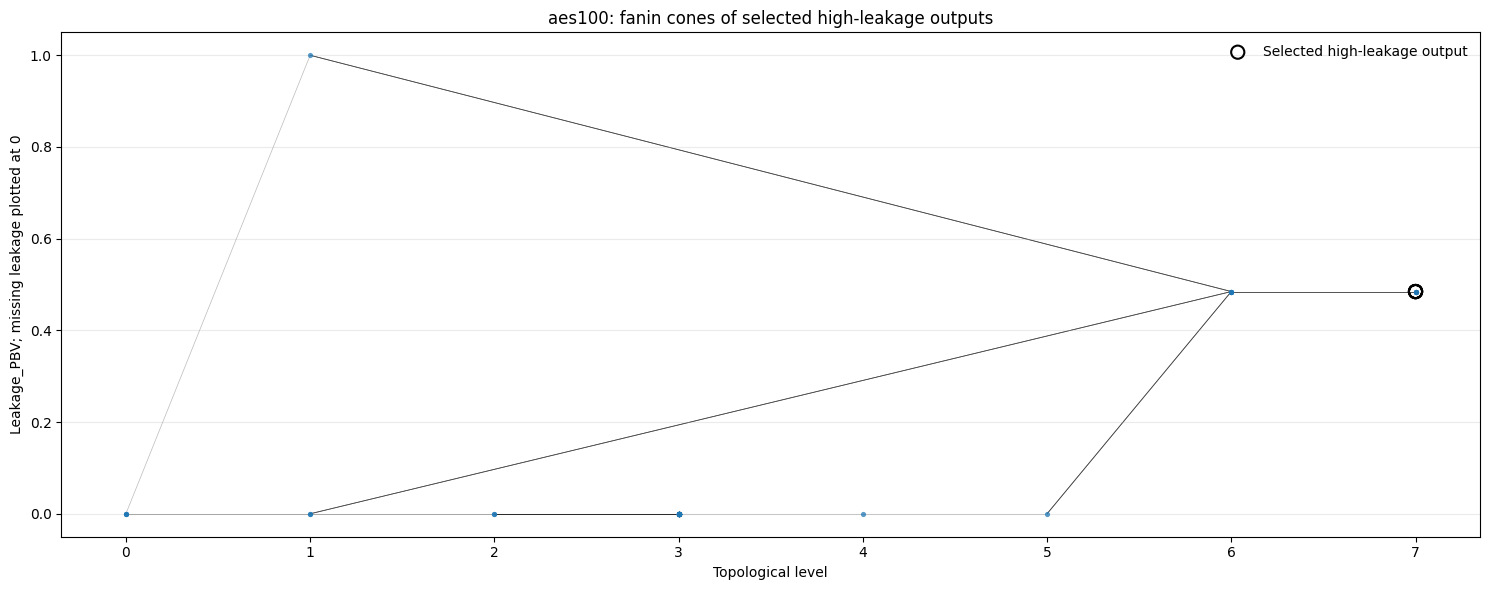

aes100: fanin-only drawable edges=111, missing edges=0, saved=fortify/analysis_outputs/leakage_topology/aes100/aes100_fanin_only.png


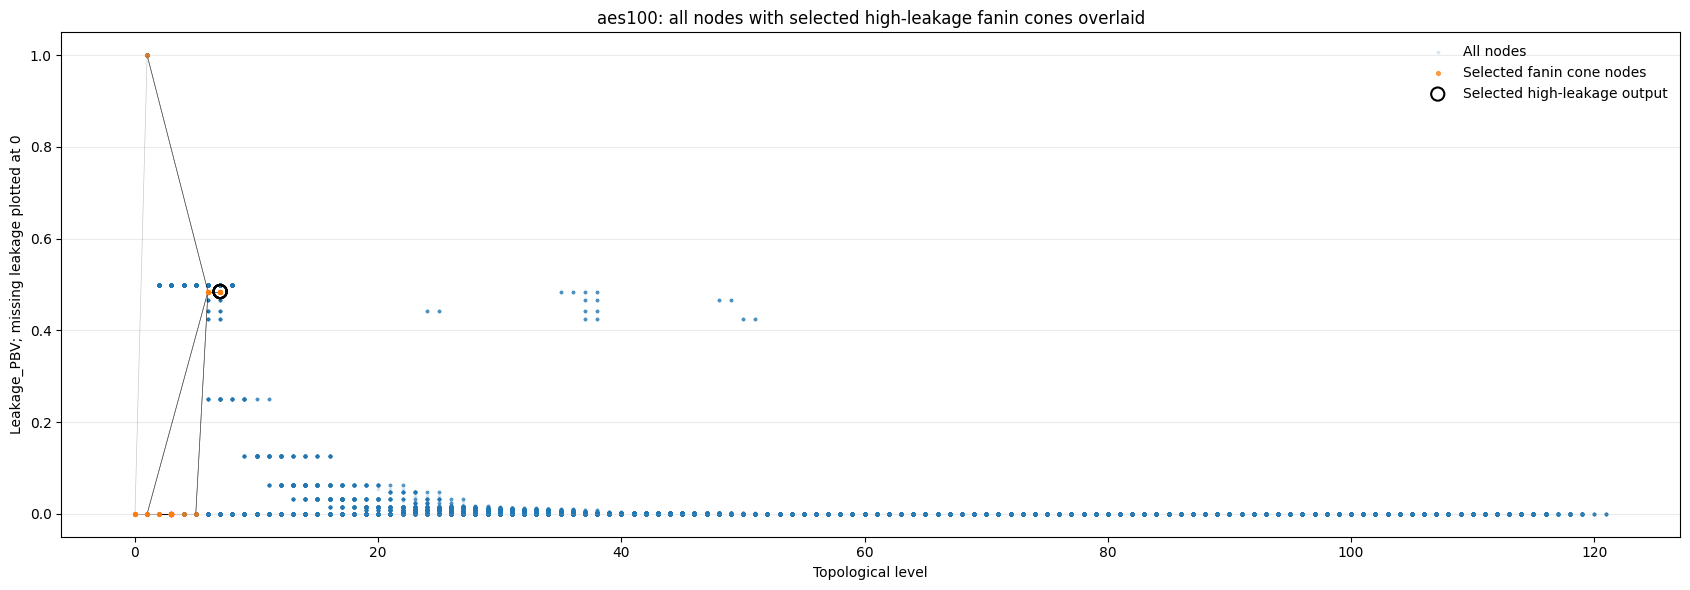

aes100: full-overlay drawable edges=111, missing edges=0, saved=fortify/analysis_outputs/leakage_topology/aes100/aes100_full_overlay.png


,design,node,topological_level,scc_size,indegree,outdegree,has_leakage,leakage,plot_leakage,best_ref,actual_signal,actual_ref,pbv,prior
9453,aes100,top.Capacitance[10:10],7,1,1,0,True,0.484691,0.484691,top.key[1:1],top.Capacitance[10:10]@20,top.key[1:1],0.742345,0.5
9455,aes100,top.Capacitance[11:11],7,1,1,0,True,0.484691,0.484691,top.key[1:1],top.Capacitance[11:11]@20,top.key[1:1],0.742345,0.5
9457,aes100,top.Capacitance[12:12],7,1,1,0,True,0.484691,0.484691,top.key[1:1],top.Capacitance[12:12]@20,top.key[1:1],0.742345,0.5
9459,aes100,top.Capacitance[13:13],7,1,1,0,True,0.484691,0.484691,top.key[1:1],top.Capacitance[13:13]@20,top.key[1:1],0.742345,0.5
9463,aes100,top.Capacitance[15:15],7,1,1,0,True,0.484691,0.484691,top.key[1:1],top.Capacitance[15:15]@20,top.key[1:1],0.742345,0.5


In [17]:

# -----------------------------
# Run one design first while tuning parameters
# -----------------------------
# Change the index to test another design.
one_bundle = analyze_design(DESIGN_SPECS[0])
one_bundle["target_df"].head(30)



=== aes100 ===
parents: fortify/results/aes/aes100_recon/parents.txt
leakage: fortify/results/aes/aes100_recon/all_signal_leakage.csv
nodes=80626, edges=98310, DAG=False
topological levels=122
leakage nodes=76298
selected targets=5, cone_nodes=61, cone_edges=111


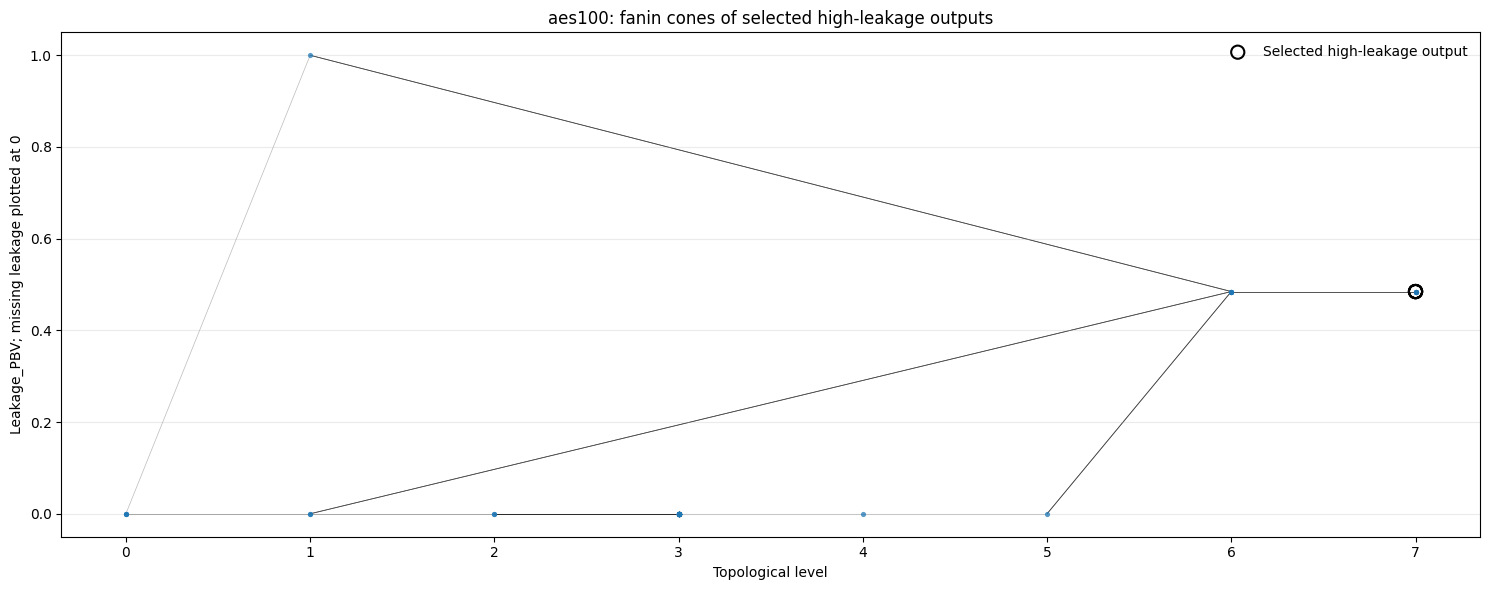

aes100: fanin-only drawable edges=111, missing edges=0, saved=fortify/analysis_outputs/leakage_topology/aes100/aes100_fanin_only.png


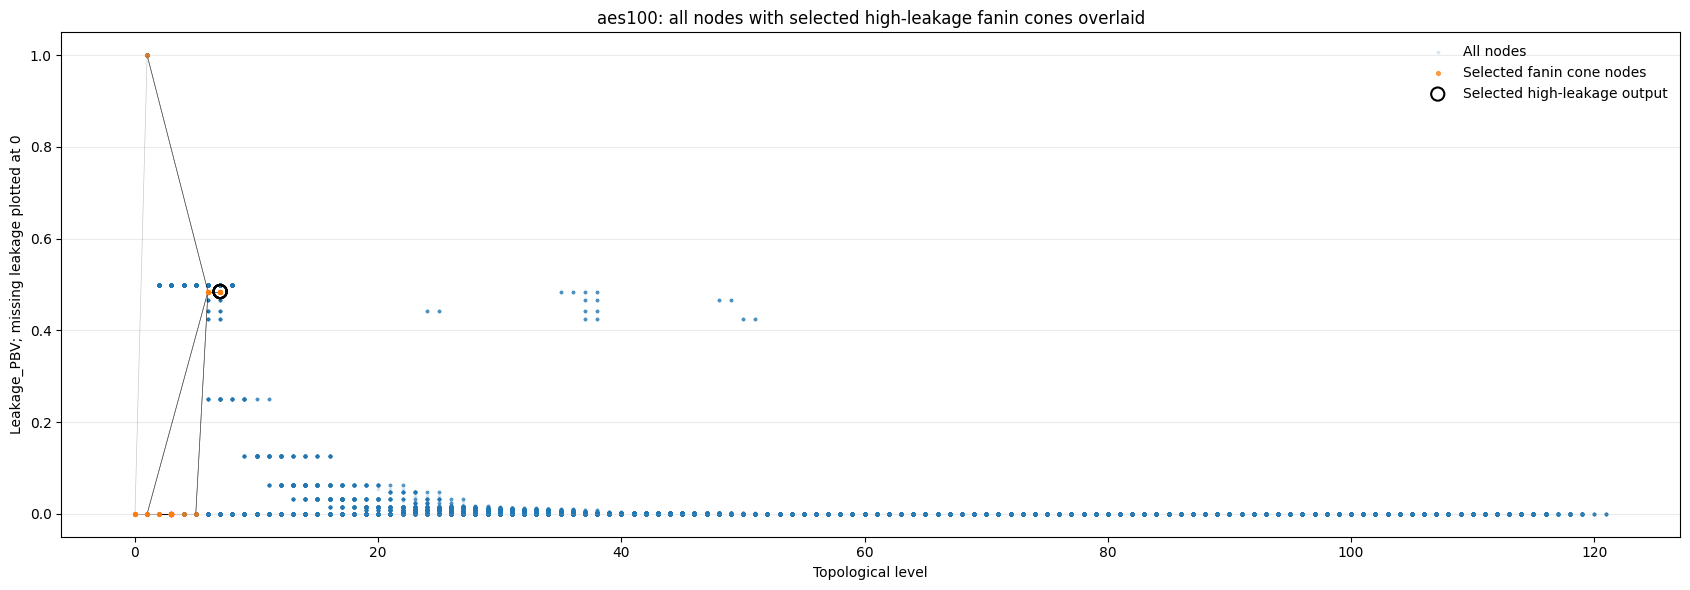

aes100: full-overlay drawable edges=111, missing edges=0, saved=fortify/analysis_outputs/leakage_topology/aes100/aes100_full_overlay.png

=== aes200 ===
parents: fortify/results/aes/aes200_recon/parents.txt
leakage: fortify/results/aes/aes200_recon/all_signal_leakage.csv
nodes=78942, edges=93958, DAG=True
topological levels=130
leakage nodes=78814
selected targets=5, cone_nodes=83, cone_edges=110


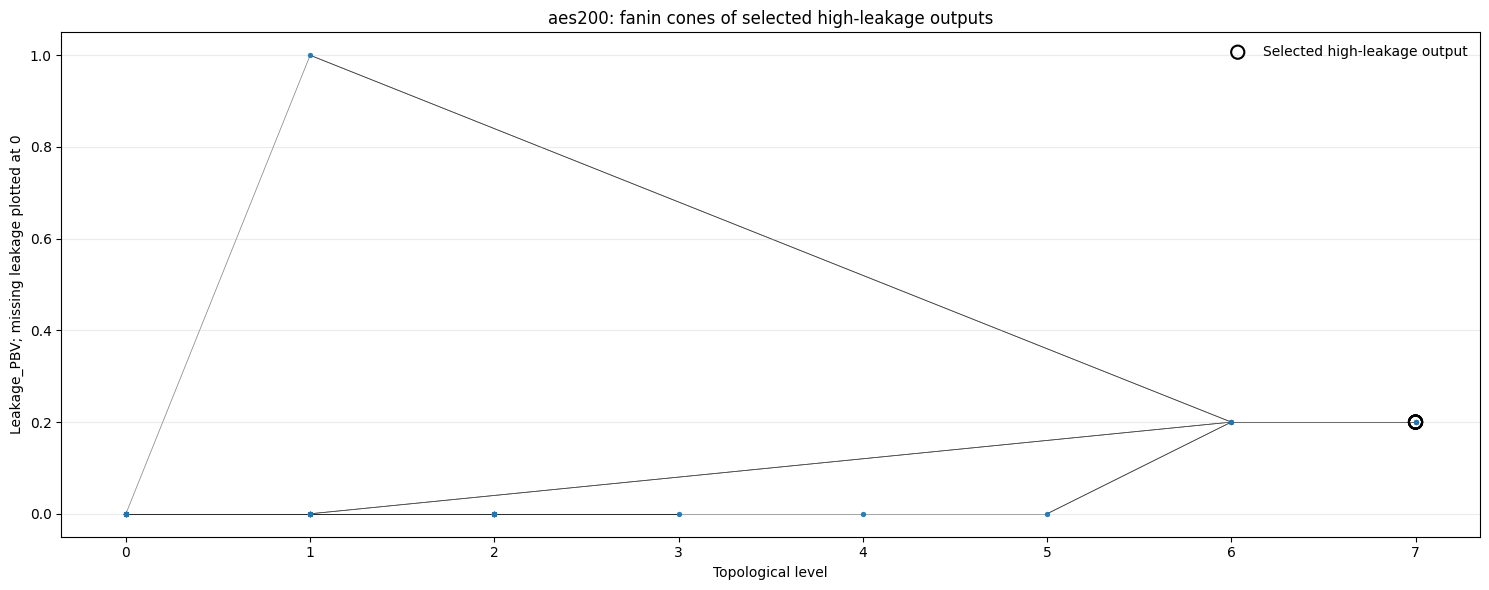

aes200: fanin-only drawable edges=110, missing edges=0, saved=fortify/analysis_outputs/leakage_topology/aes200/aes200_fanin_only.png


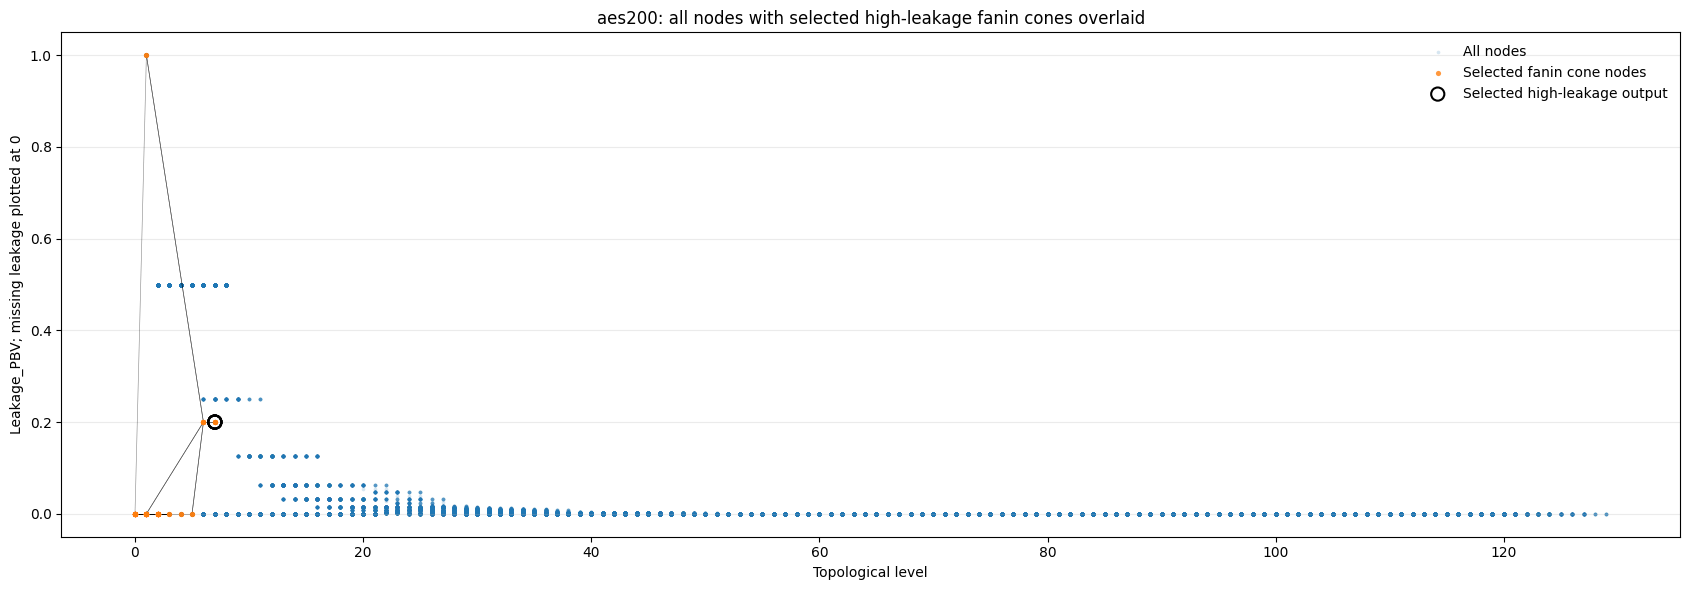

aes200: full-overlay drawable edges=110, missing edges=0, saved=fortify/analysis_outputs/leakage_topology/aes200/aes200_full_overlay.png

=== aes700 ===
parents: fortify/results/aes/aes700_recon/parents.txt
leakage: fortify/results/aes/aes700_recon/all_signal_leakage.csv
nodes=80760, edges=99303, DAG=False
topological levels=122
leakage nodes=76432
selected targets=5, cone_nodes=62, cone_edges=131


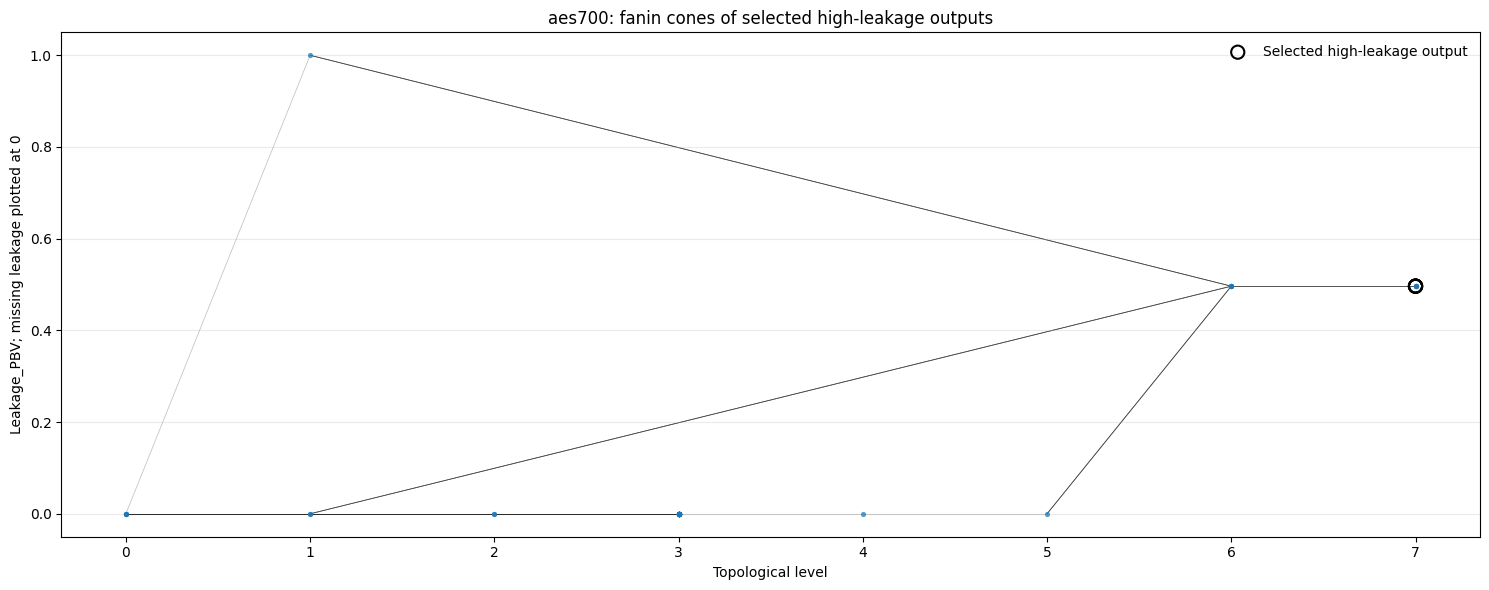

aes700: fanin-only drawable edges=131, missing edges=0, saved=fortify/analysis_outputs/leakage_topology/aes700/aes700_fanin_only.png


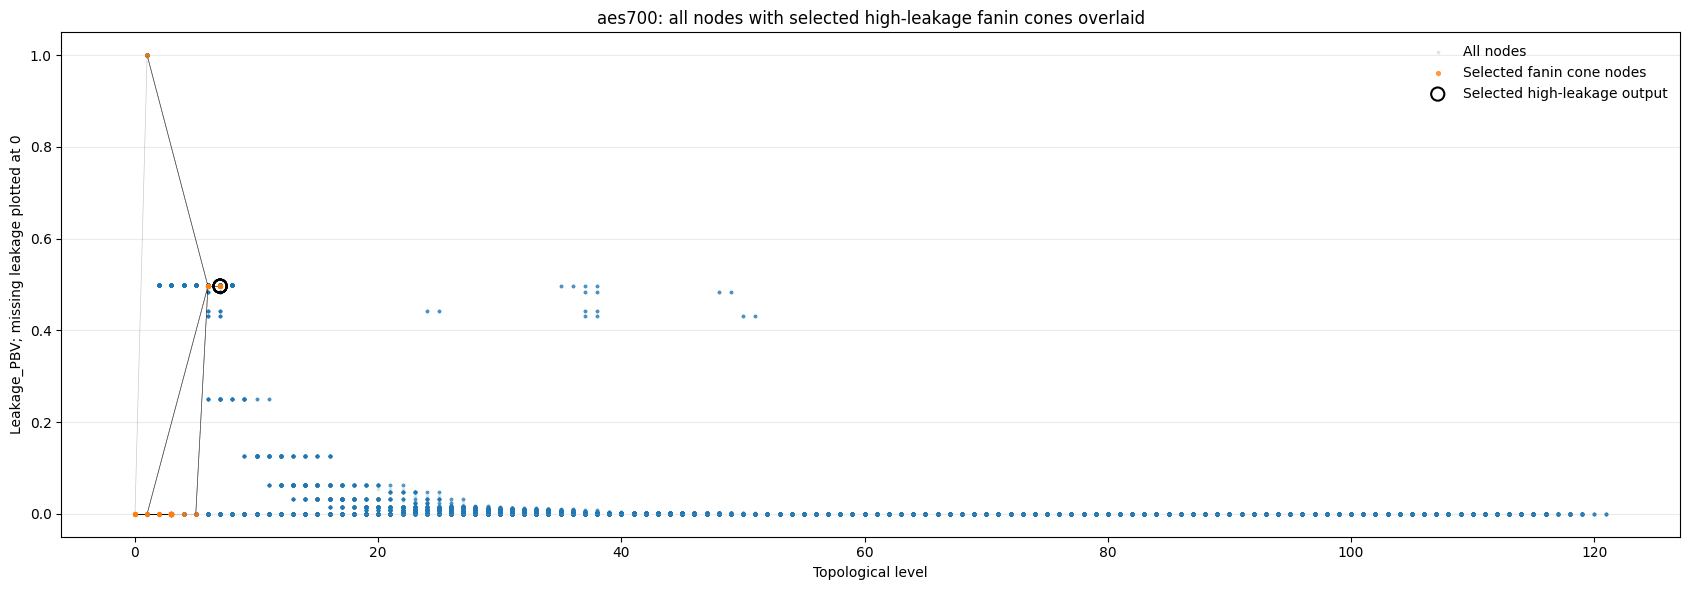

aes700: full-overlay drawable edges=131, missing edges=0, saved=fortify/analysis_outputs/leakage_topology/aes700/aes700_full_overlay.png

=== aes800 ===
parents: fortify/results/aes/aes800_recon/parents.txt
leakage: fortify/results/aes/aes800_recon/all_signal_leakage.csv
nodes=83253, edges=101792, DAG=False
topological levels=130
leakage nodes=78925
selected targets=5, cone_nodes=86, cone_edges=154


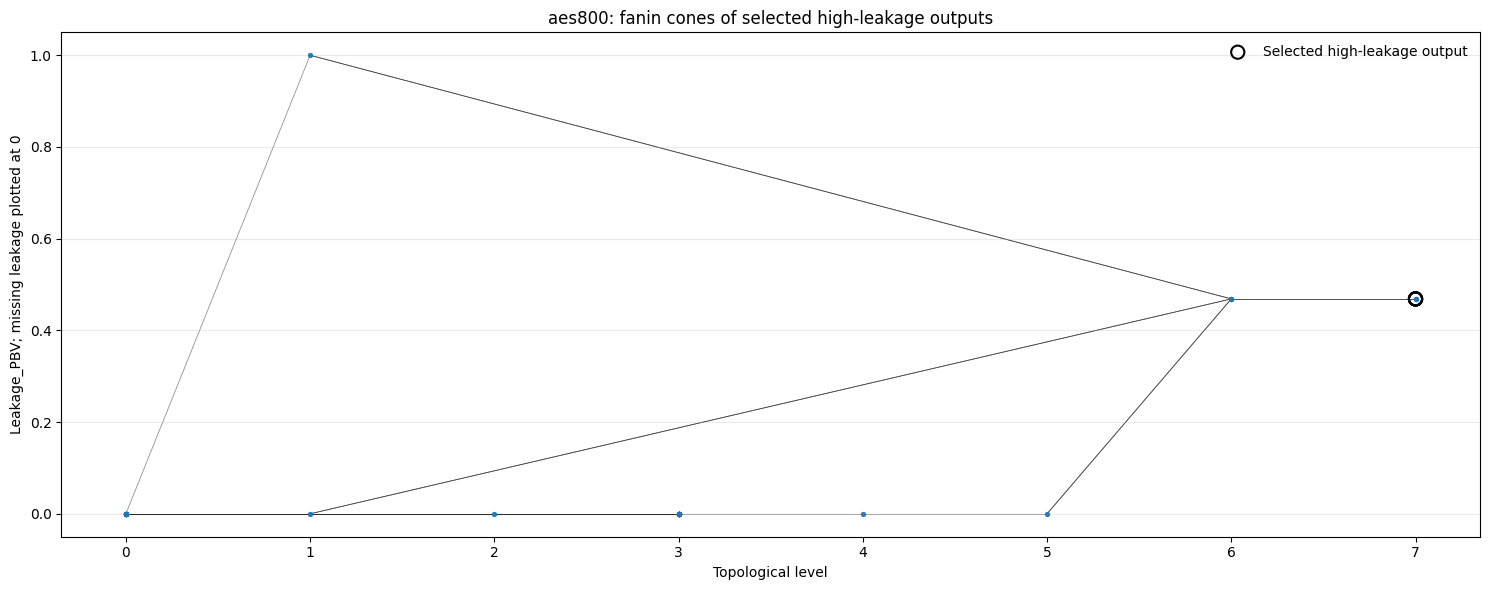

aes800: fanin-only drawable edges=154, missing edges=0, saved=fortify/analysis_outputs/leakage_topology/aes800/aes800_fanin_only.png


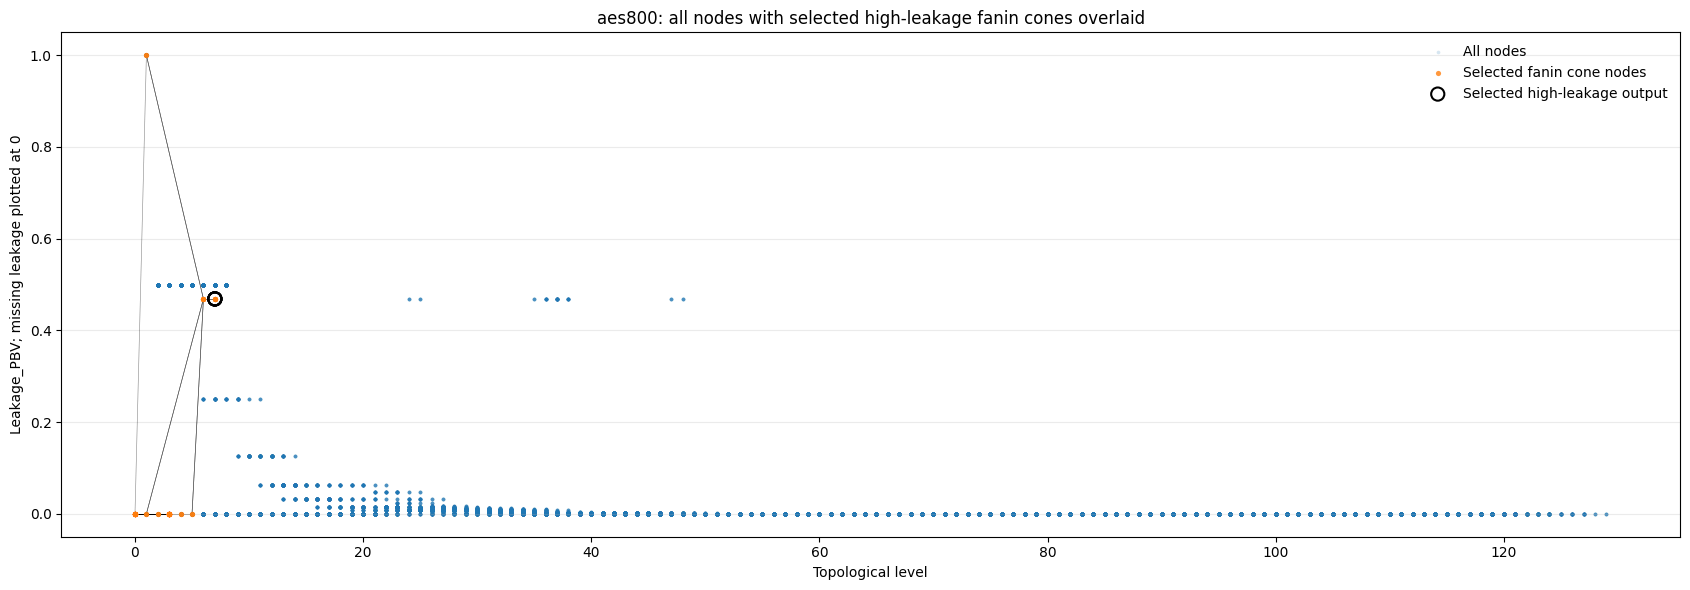

aes800: full-overlay drawable edges=154, missing edges=0, saved=fortify/analysis_outputs/leakage_topology/aes800/aes800_full_overlay.png

=== aes1100 ===
parents: fortify/results/aes/aes1100_recon/parents.txt
leakage: fortify/results/aes/aes1100_recon/all_signal_leakage.csv
nodes=83253, edges=102176, DAG=False
topological levels=130
leakage nodes=78925
selected targets=5, cone_nodes=86, cone_edges=154


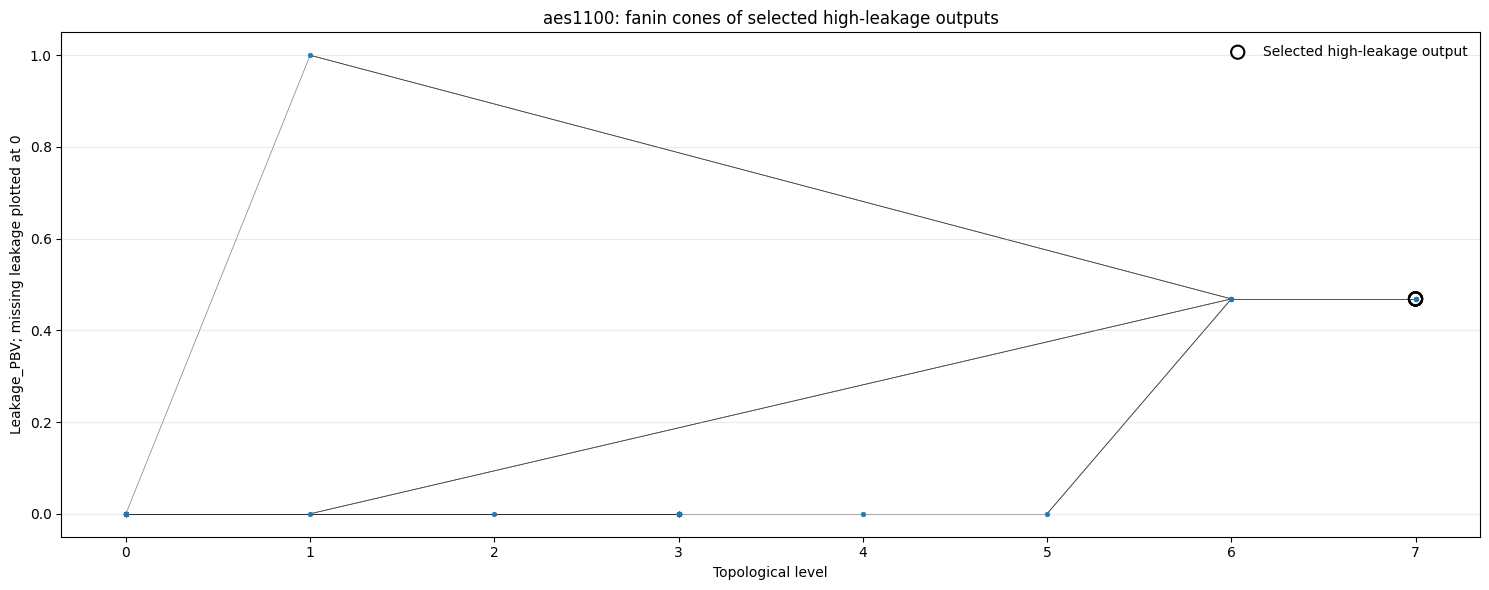

aes1100: fanin-only drawable edges=154, missing edges=0, saved=fortify/analysis_outputs/leakage_topology/aes1100/aes1100_fanin_only.png


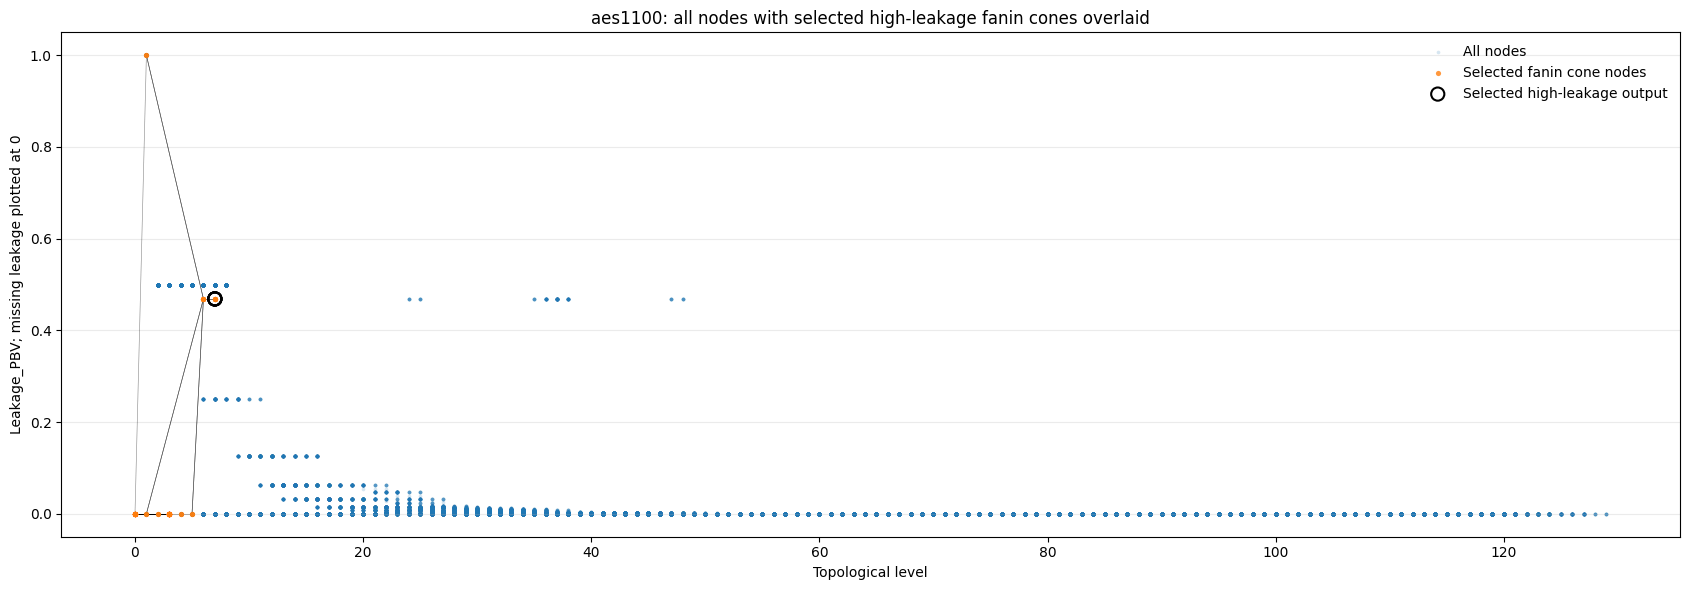

aes1100: full-overlay drawable edges=154, missing edges=0, saved=fortify/analysis_outputs/leakage_topology/aes1100/aes1100_full_overlay.png

=== aes1200 ===
parents: fortify/results/aes/aes1200_recon/parents.txt
leakage: fortify/results/aes/aes1200_recon/all_signal_leakage.csv
nodes=120635, edges=181987, DAG=False
topological levels=471
leakage nodes=76580
selected targets=5, cone_nodes=82, cone_edges=151


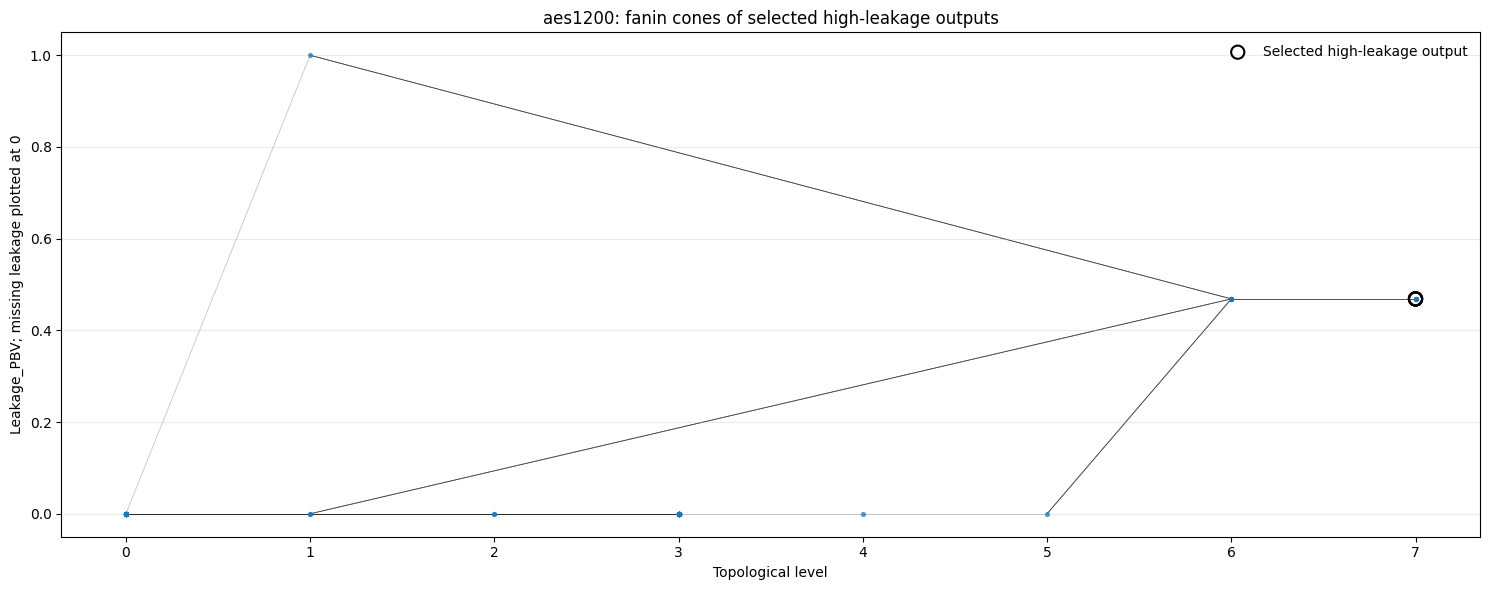

aes1200: fanin-only drawable edges=151, missing edges=0, saved=fortify/analysis_outputs/leakage_topology/aes1200/aes1200_fanin_only.png


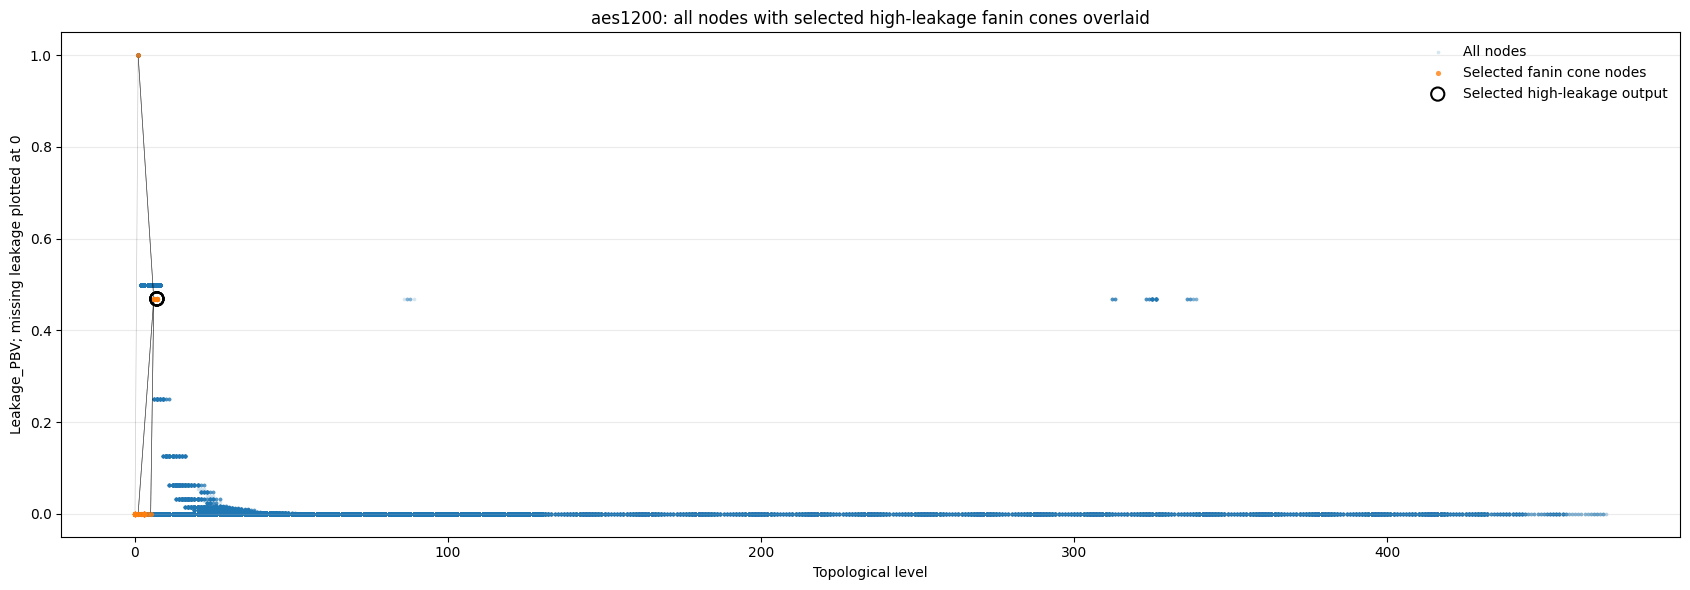

aes1200: full-overlay drawable edges=151, missing edges=0, saved=fortify/analysis_outputs/leakage_topology/aes1200/aes1200_full_overlay.png

=== aes1600 ===
parents: fortify/results/aes/aes1600_recon/parents.txt
leakage: fortify/results/aes/aes1600_recon/all_signal_leakage.csv
nodes=83259, edges=536567, DAG=False
topological levels=130
leakage nodes=78686
selected targets=0, cone_nodes=0, cone_edges=0


/tmp/ipykernel_68774/1004285898.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


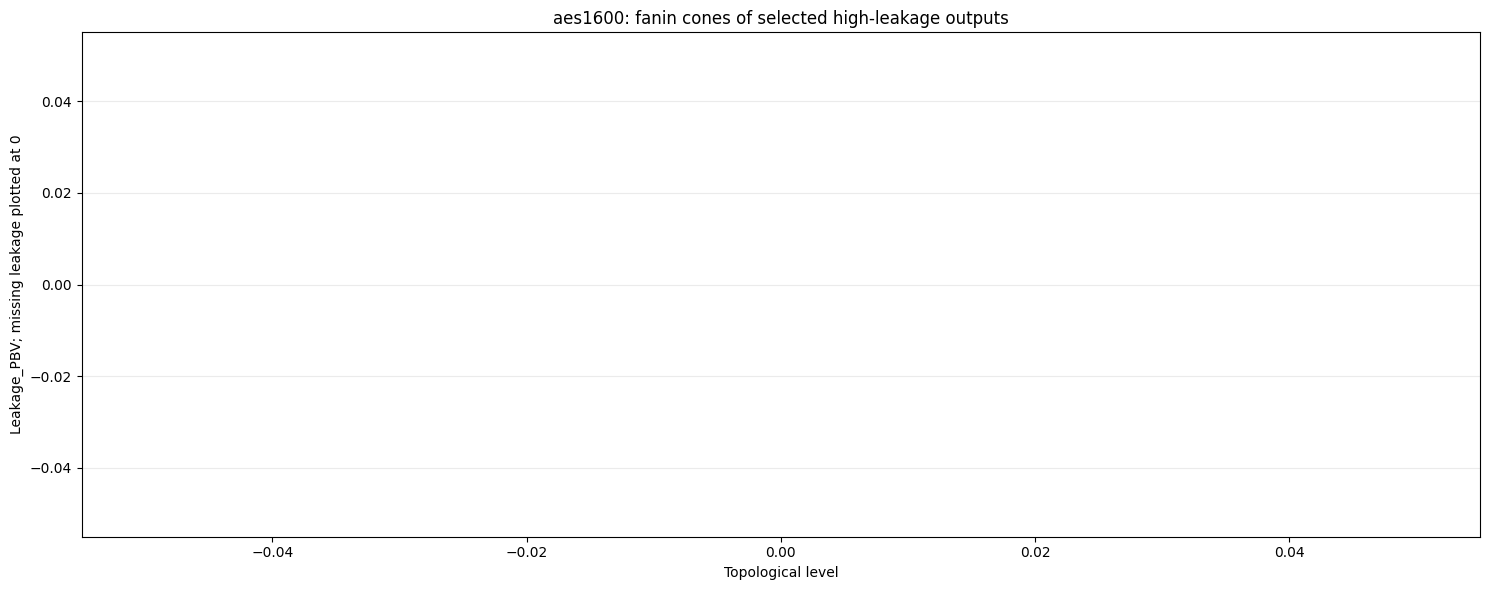

aes1600: fanin-only drawable edges=0, missing edges=0, saved=fortify/analysis_outputs/leakage_topology/aes1600/aes1600_fanin_only.png


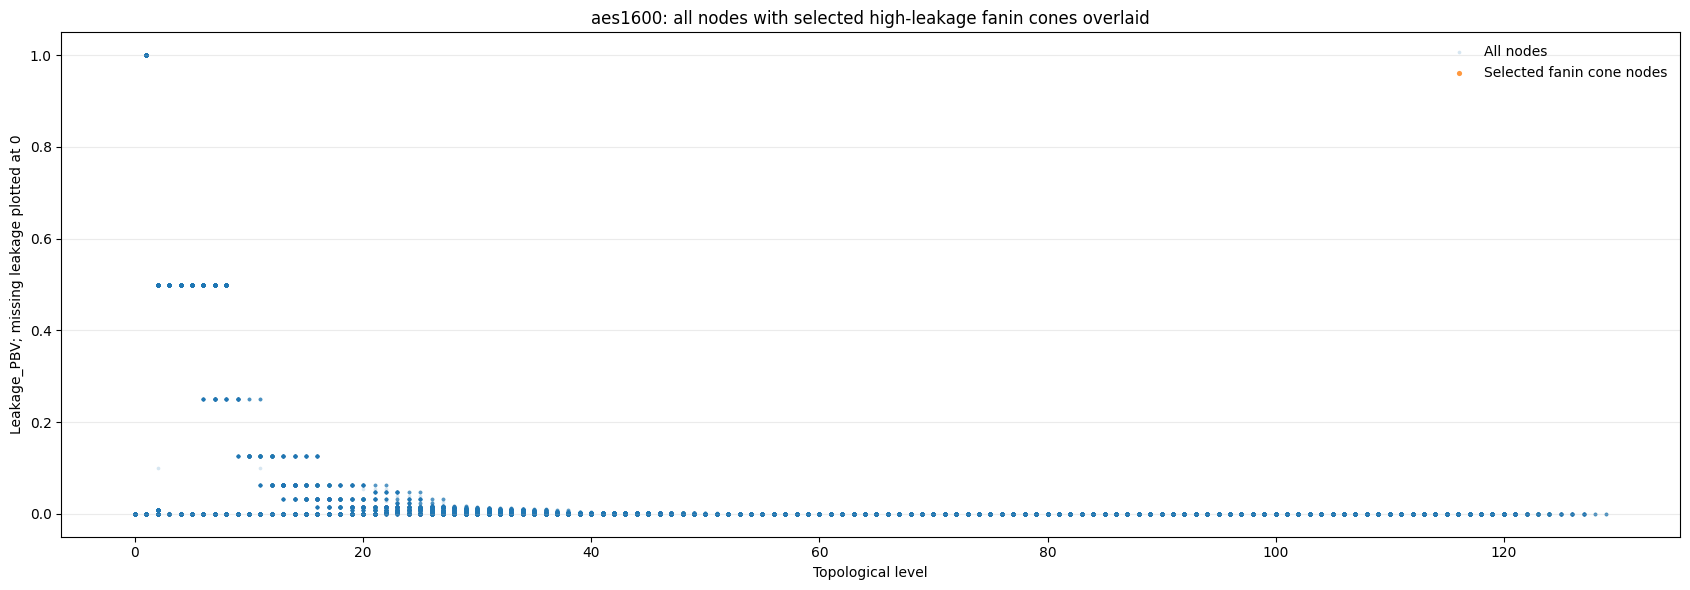

aes1600: full-overlay drawable edges=0, missing edges=0, saved=fortify/analysis_outputs/leakage_topology/aes1600/aes1600_full_overlay.png

=== aes1700 ===
parents: fortify/results/aes/aes1700_recon/parents.txt
leakage: fortify/results/aes/aes1700_recon/all_signal_leakage.csv
nodes=116718, edges=2246781, DAG=True
topological levels=135
leakage nodes=78773
selected targets=0, cone_nodes=0, cone_edges=0


/tmp/ipykernel_68774/1004285898.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


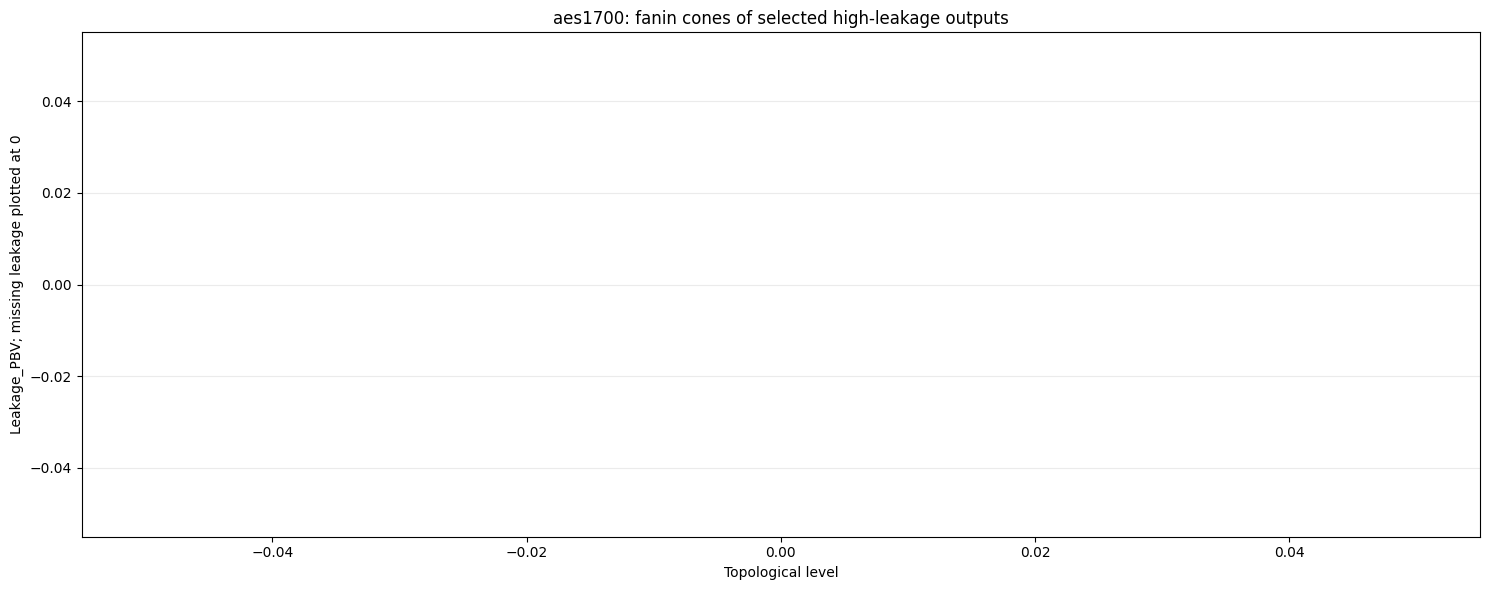

aes1700: fanin-only drawable edges=0, missing edges=0, saved=fortify/analysis_outputs/leakage_topology/aes1700/aes1700_fanin_only.png


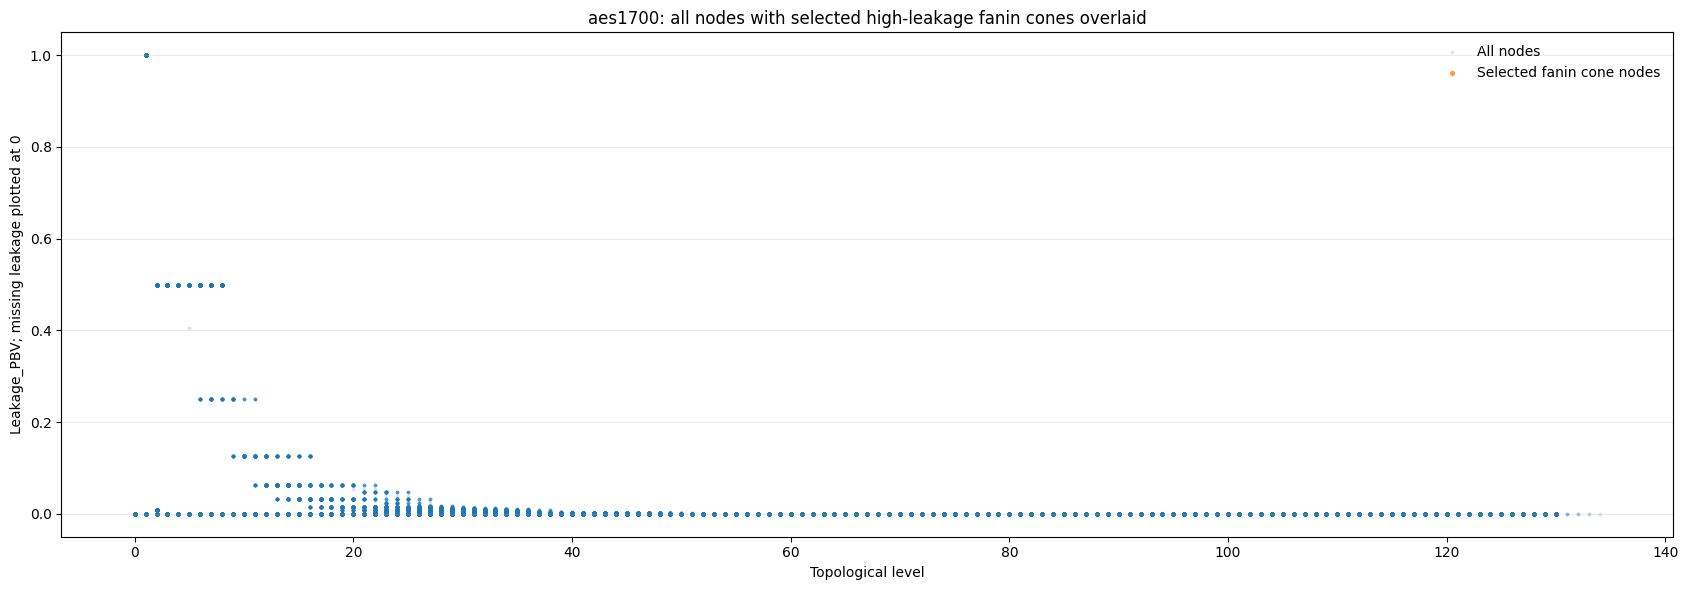

aes1700: full-overlay drawable edges=0, missing edges=0, saved=fortify/analysis_outputs/leakage_topology/aes1700/aes1700_full_overlay.png
combined aes100: targets=5, cone_nodes=61, drawn_edges=111, missing_edges=0
combined aes200: targets=5, cone_nodes=83, drawn_edges=110, missing_edges=0
combined aes700: targets=5, cone_nodes=62, drawn_edges=131, missing_edges=0
combined aes800: targets=5, cone_nodes=86, drawn_edges=154, missing_edges=0
combined aes1100: targets=5, cone_nodes=86, drawn_edges=154, missing_edges=0
combined aes1200: targets=5, cone_nodes=82, drawn_edges=151, missing_edges=0
combined aes1600: targets=0, cone_nodes=0, drawn_edges=0, missing_edges=0
combined aes1700: targets=0, cone_nodes=0, drawn_edges=0, missing_edges=0


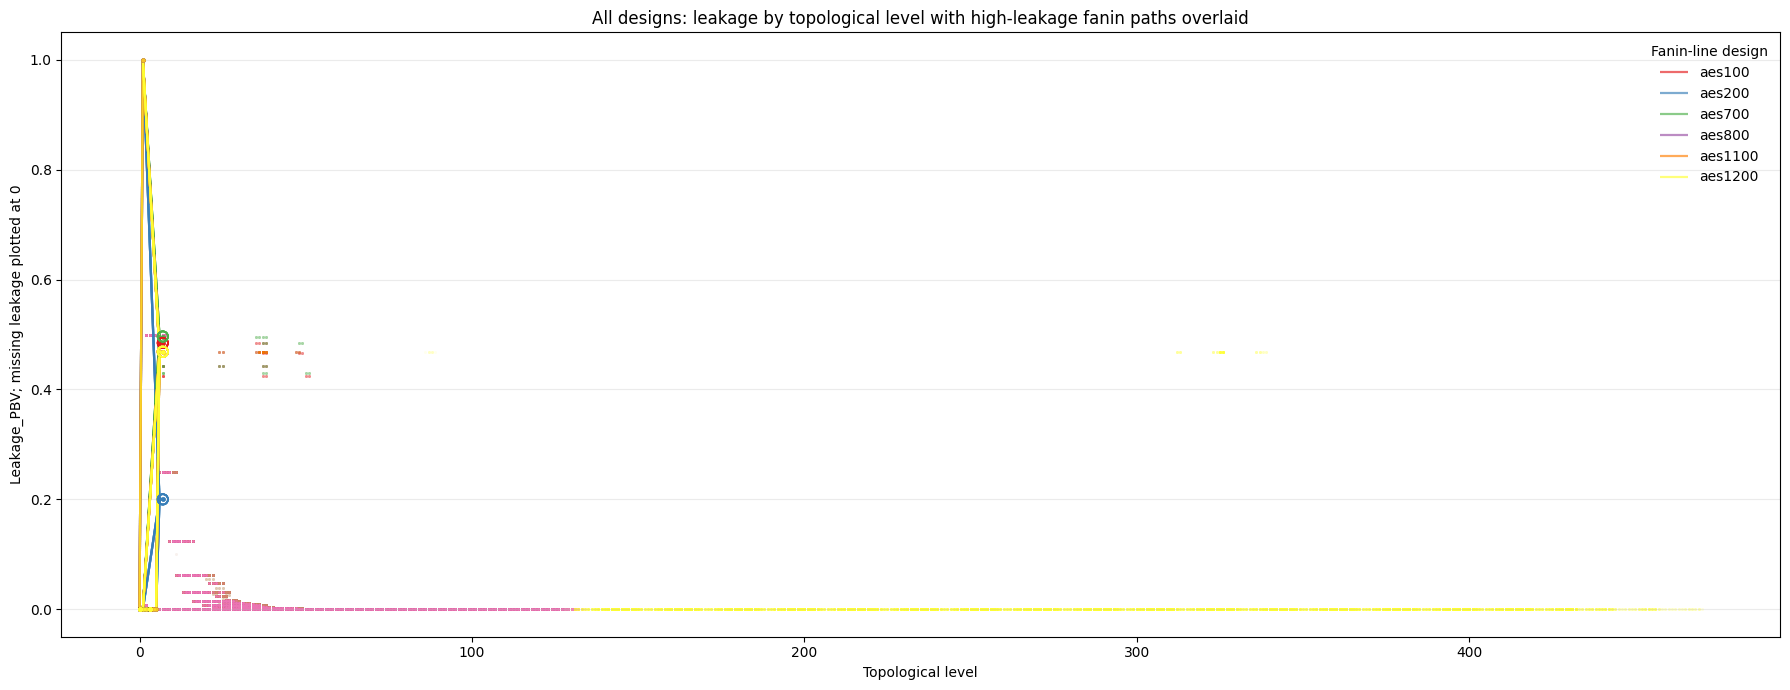

Saved combined plot to: fortify/analysis_outputs/leakage_topology/combined_full_overlay_by_design.png


,design,nodes,edges,is_dag,topological_levels,leakage_nodes,selected_targets,fanin_nodes,fanin_edges
0,aes100,80626,98310,False,122,76298,5,61,111
1,aes200,78942,93958,True,130,78814,5,83,110
2,aes700,80760,99303,False,122,76432,5,62,131
3,aes800,83253,101792,False,130,78925,5,86,154
4,aes1100,83253,102176,False,130,78925,5,86,154
5,aes1200,120635,181987,False,471,76580,5,82,151
6,aes1600,83259,536567,False,130,78686,0,0,0
7,aes1700,116718,2246781,True,135,78773,0,0,0


In [18]:

# -----------------------------
# Run all designs and create combined plot
# -----------------------------
# After tuning the config above, run this cell.

all_bundles = []
errors = []

for spec in DESIGN_SPECS:
    try:
        bundle = analyze_design(spec)
        all_bundles.append(bundle)
    except Exception as exc:
        errors.append((spec["design"], str(exc)))
        print(f"Skipping {spec['design']}: {exc}")

combined_plot = plot_combined_full_overlay(all_bundles)

summary_rows = []
for b in all_bundles:
    G = b["graph"]
    df = b["node_df"]
    summary_rows.append({
        "design": b["design"],
        "nodes": G.number_of_nodes(),
        "edges": G.number_of_edges(),
        "is_dag": nx.is_directed_acyclic_graph(G),
        "topological_levels": int(df["topological_level"].max() + 1) if len(df) else 0,
        "leakage_nodes": int(df["has_leakage"].sum()),
        "selected_targets": len(b["targets"]),
        "fanin_nodes": len(b["cone_nodes"]),
        "fanin_edges": len(b["cone_edges"]),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUTPUT_ROOT / "analysis_summary.csv", index=False)
summary_df


In [19]:

# -----------------------------
# Optional: inspect top selected targets across all designs
# -----------------------------

target_tables = []
for b in all_bundles if 'all_bundles' in globals() else [one_bundle]:
    tdf = b["target_df"].copy()
    tdf["design"] = b["design"]
    target_tables.append(tdf)

if target_tables:
    all_targets_df = pd.concat(target_tables, ignore_index=True)
    display(all_targets_df.sort_values(["leakage"], ascending=False).head(100))
else:
    print("No target tables available yet.")


,design,node,topological_level,scc_size,indegree,outdegree,has_leakage,leakage,plot_leakage,best_ref,actual_signal,actual_ref,pbv,prior
12,aes700,top.Capacitance[12:12],7,1,1,0,True,0.496403,0.496403,top.key[1:1],top.Capacitance[12:12]@20,top.key[1:1],0.748201,0.5
13,aes700,top.Capacitance[13:13],7,1,1,0,True,0.496403,0.496403,top.key[1:1],top.Capacitance[13:13]@20,top.key[1:1],0.748201,0.5
10,aes700,top.Capacitance[10:10],7,1,1,0,True,0.496403,0.496403,top.key[1:1],top.Capacitance[10:10]@20,top.key[1:1],0.748201,0.5
11,aes700,top.Capacitance[11:11],7,1,1,0,True,0.496403,0.496403,top.key[1:1],top.Capacitance[11:11]@20,top.key[1:1],0.748201,0.5
14,aes700,top.Capacitance[15:15],7,1,1,0,True,0.496403,0.496403,top.key[1:1],top.Capacitance[15:15]@20,top.key[1:1],0.748201,0.5
0,aes100,top.Capacitance[10:10],7,1,1,0,True,0.484691,0.484691,top.key[1:1],top.Capacitance[10:10]@20,top.key[1:1],0.742345,0.5
3,aes100,top.Capacitance[13:13],7,1,1,0,True,0.484691,0.484691,top.key[1:1],top.Capacitance[13:13]@20,top.key[1:1],0.742345,0.5
4,aes100,top.Capacitance[15:15],7,1,1,0,True,0.484691,0.484691,top.key[1:1],top.Capacitance[15:15]@20,top.key[1:1],0.742345,0.5
2,aes100,top.Capacitance[12:12],7,1,1,0,True,0.484691,0.484691,top.key[1:1],top.Capacitance[12:12]@20,top.key[1:1],0.742345,0.5
1,aes100,top.Capacitance[11:11],7,1,1,0,True,0.484691,0.484691,top.key[1:1],top.Capacitance[11:11]@20,top.key[1:1],0.742345,0.5



# Trojan-output candidate mining

This section ranks output-like nodes as potential Trojan outputs using distributional and path-based statistics rather than a fixed leakage threshold alone. It scores every candidate output node, computes its fanin cone, compares that cone against the rest of the design, and saves per-design plus combined candidate tables.


aes100: scoring 200 output-like candidate nodes


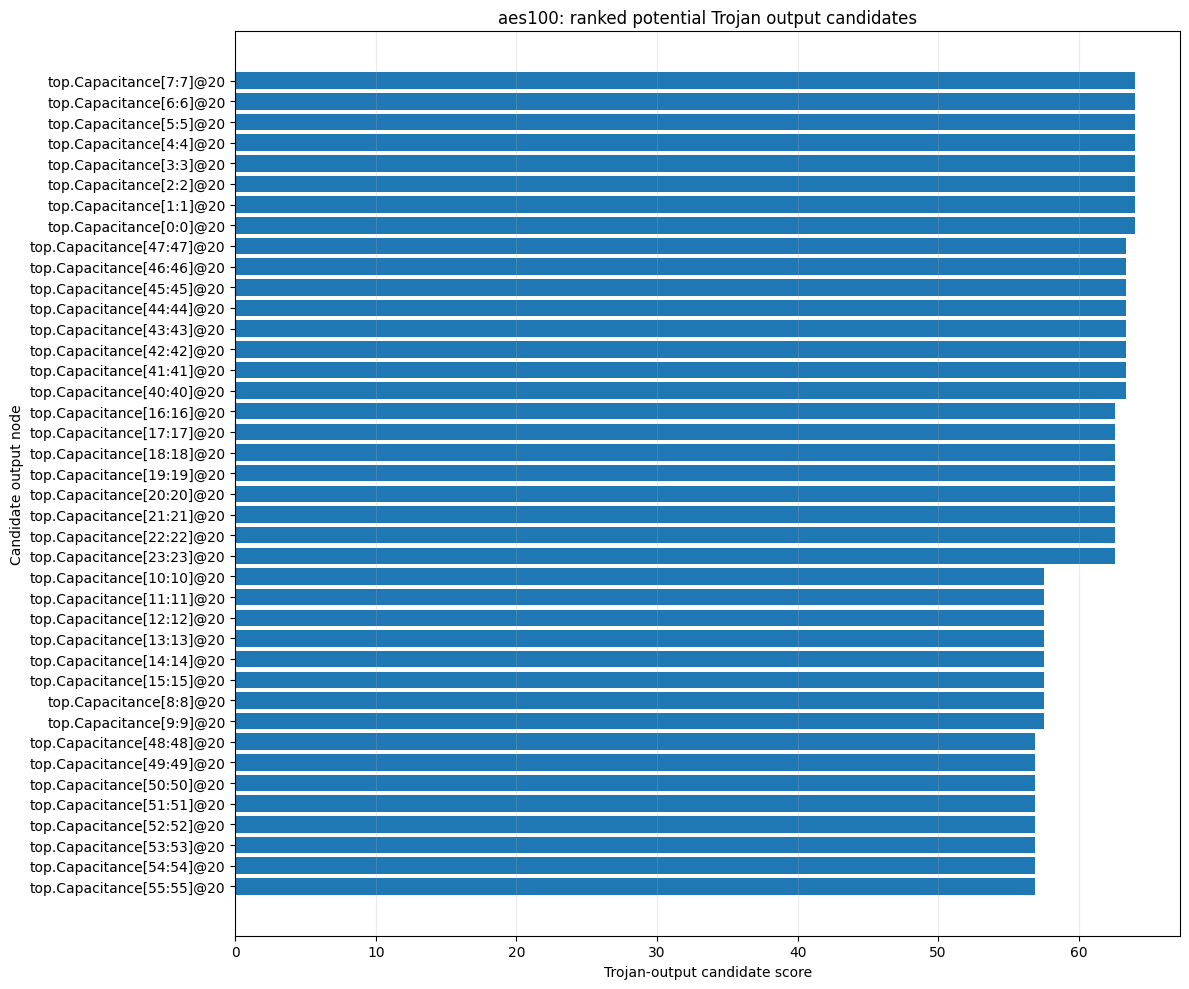

aes100: top potential Trojan outputs
aes200: scoring 200 output-like candidate nodes


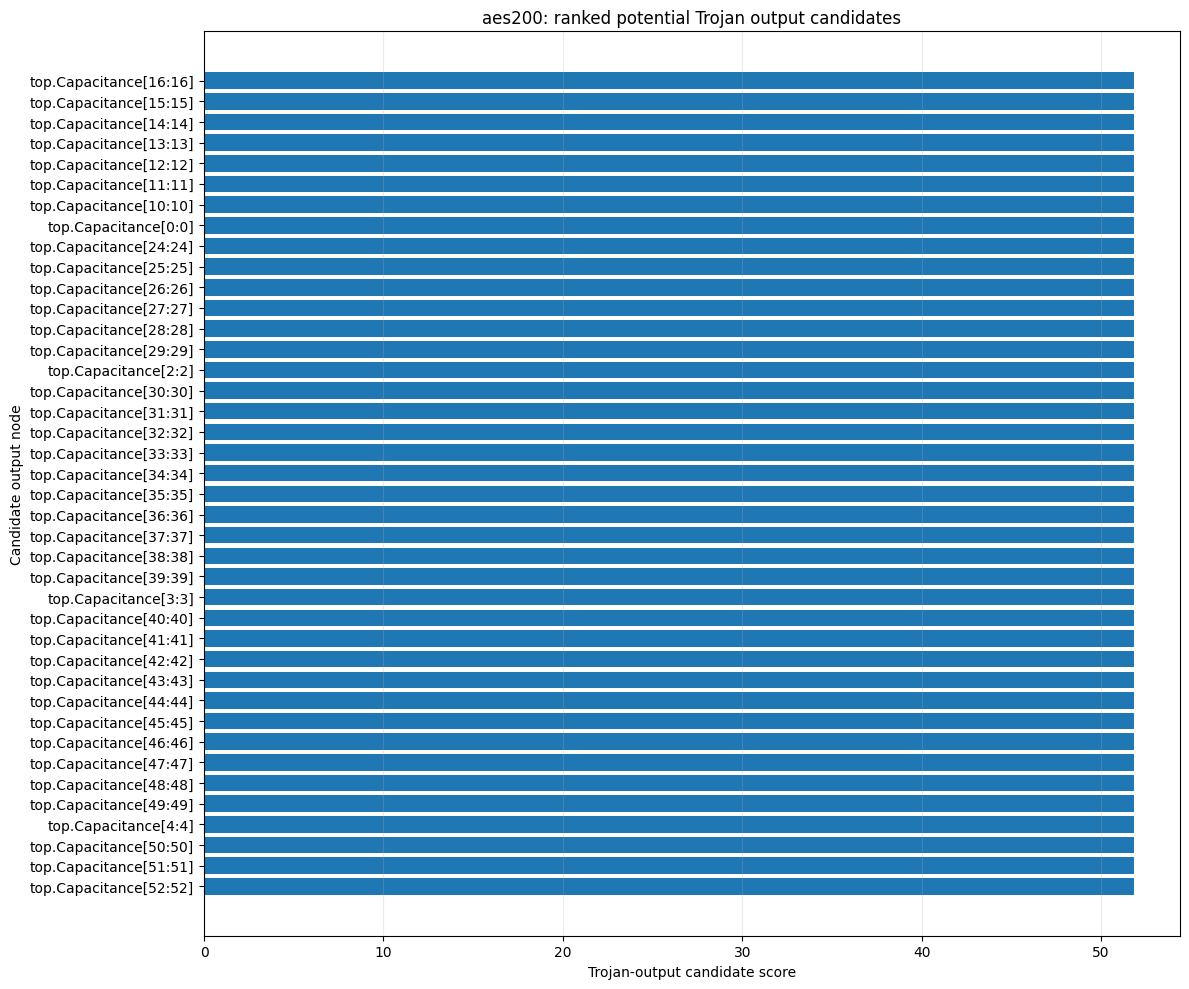

aes200: top potential Trojan outputs
aes700: scoring 200 output-like candidate nodes


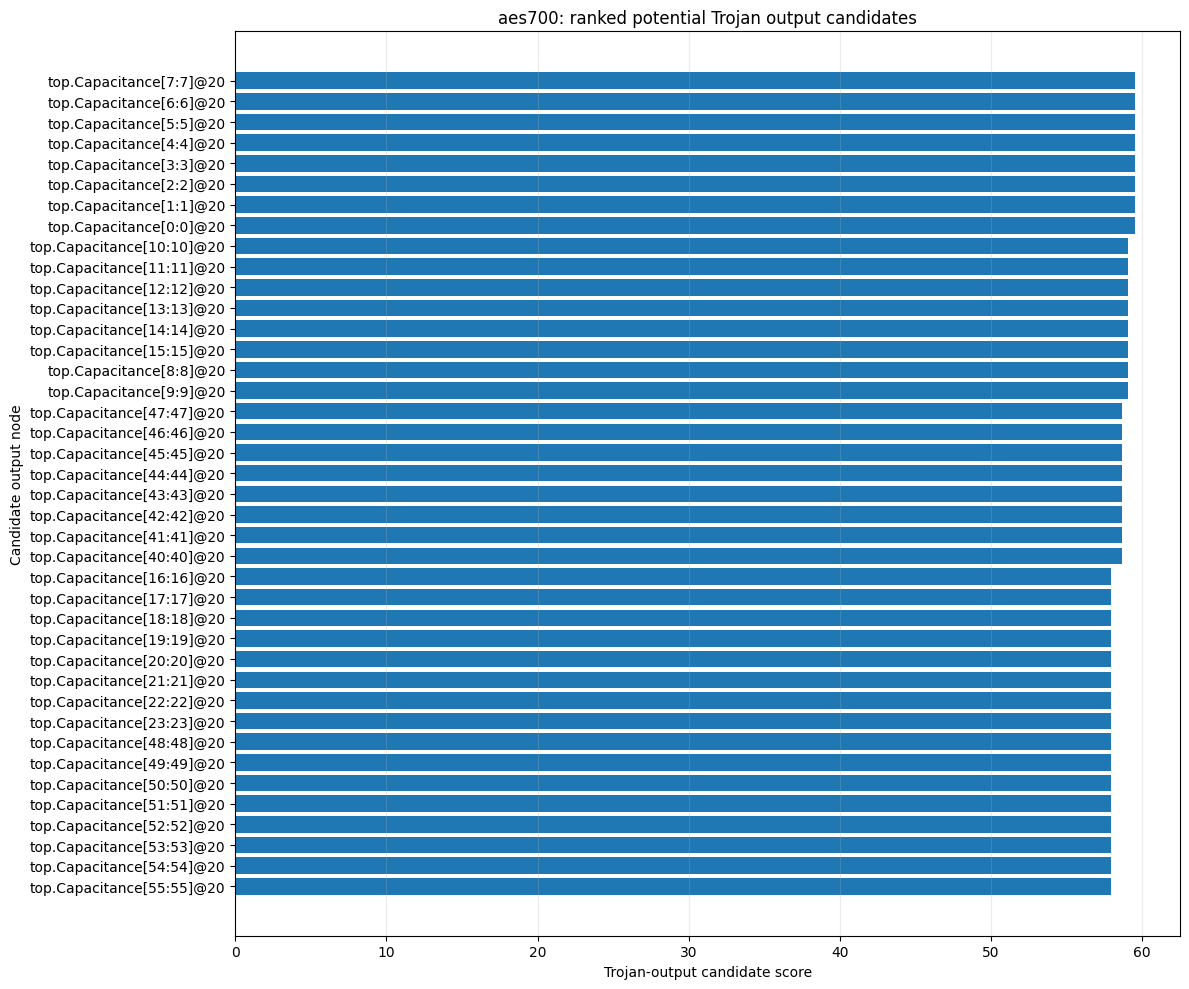

aes700: top potential Trojan outputs
aes800: scoring 200 output-like candidate nodes


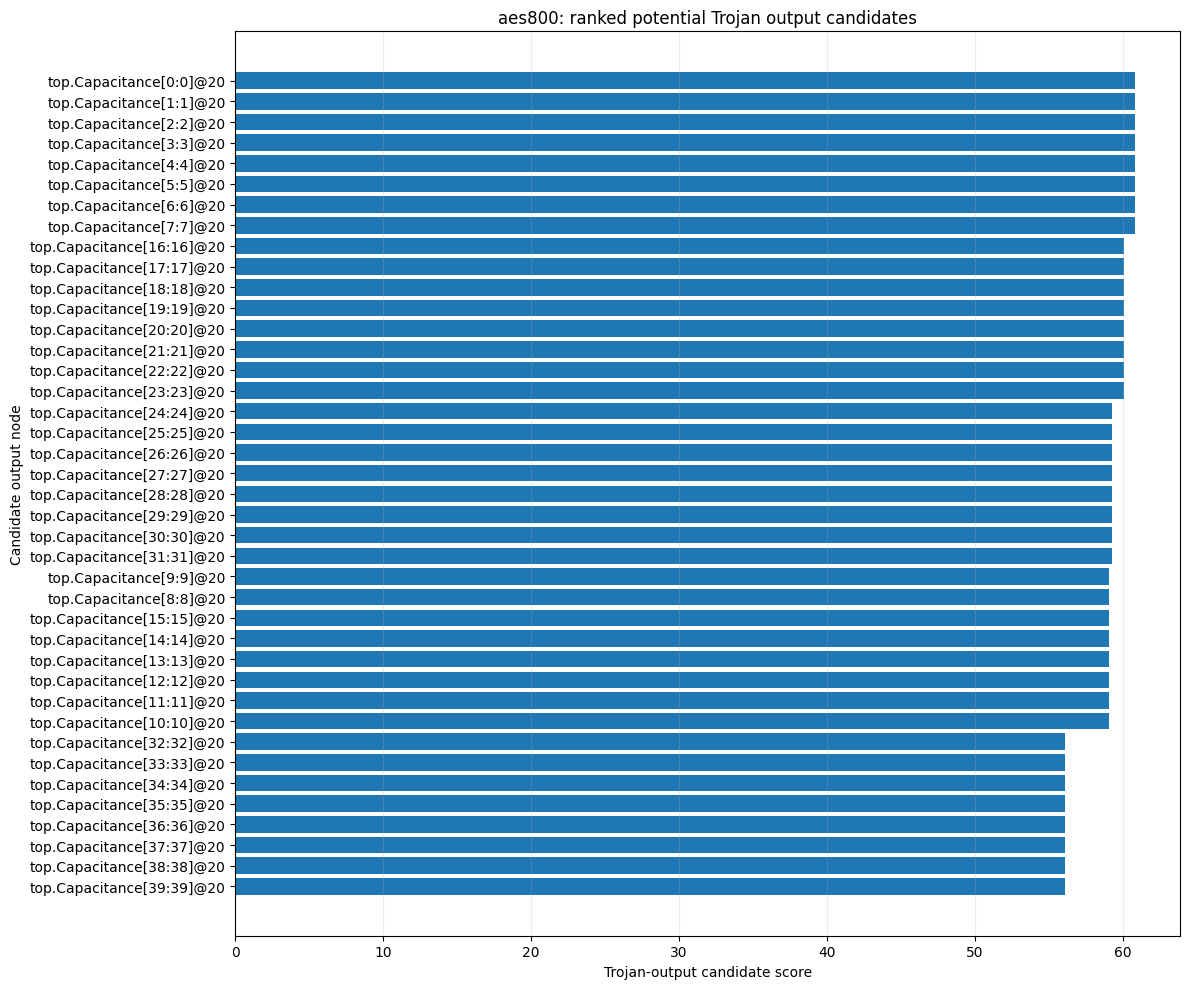

aes800: top potential Trojan outputs
aes1100: scoring 200 output-like candidate nodes


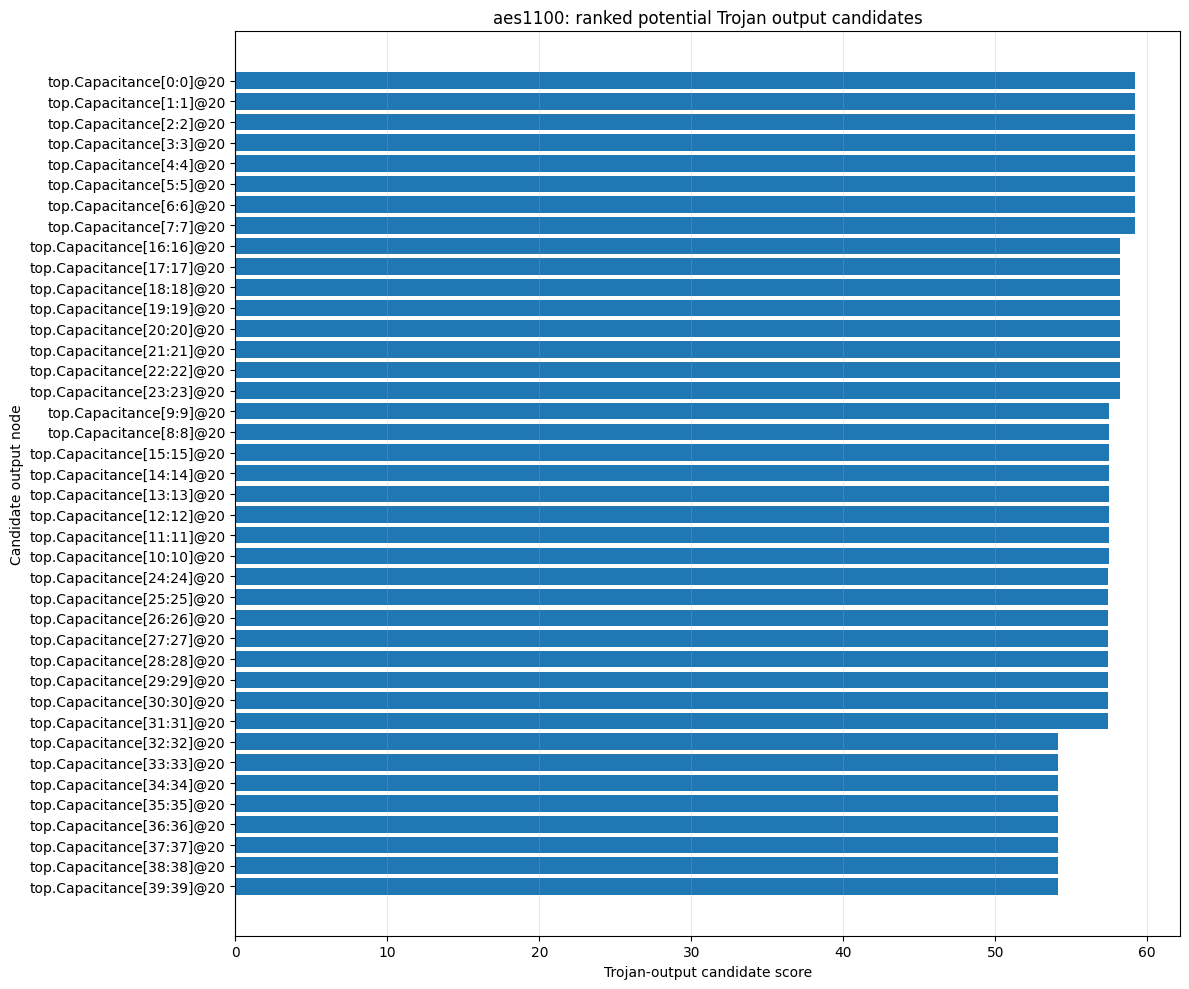

aes1100: top potential Trojan outputs
aes1200: scoring 200 output-like candidate nodes


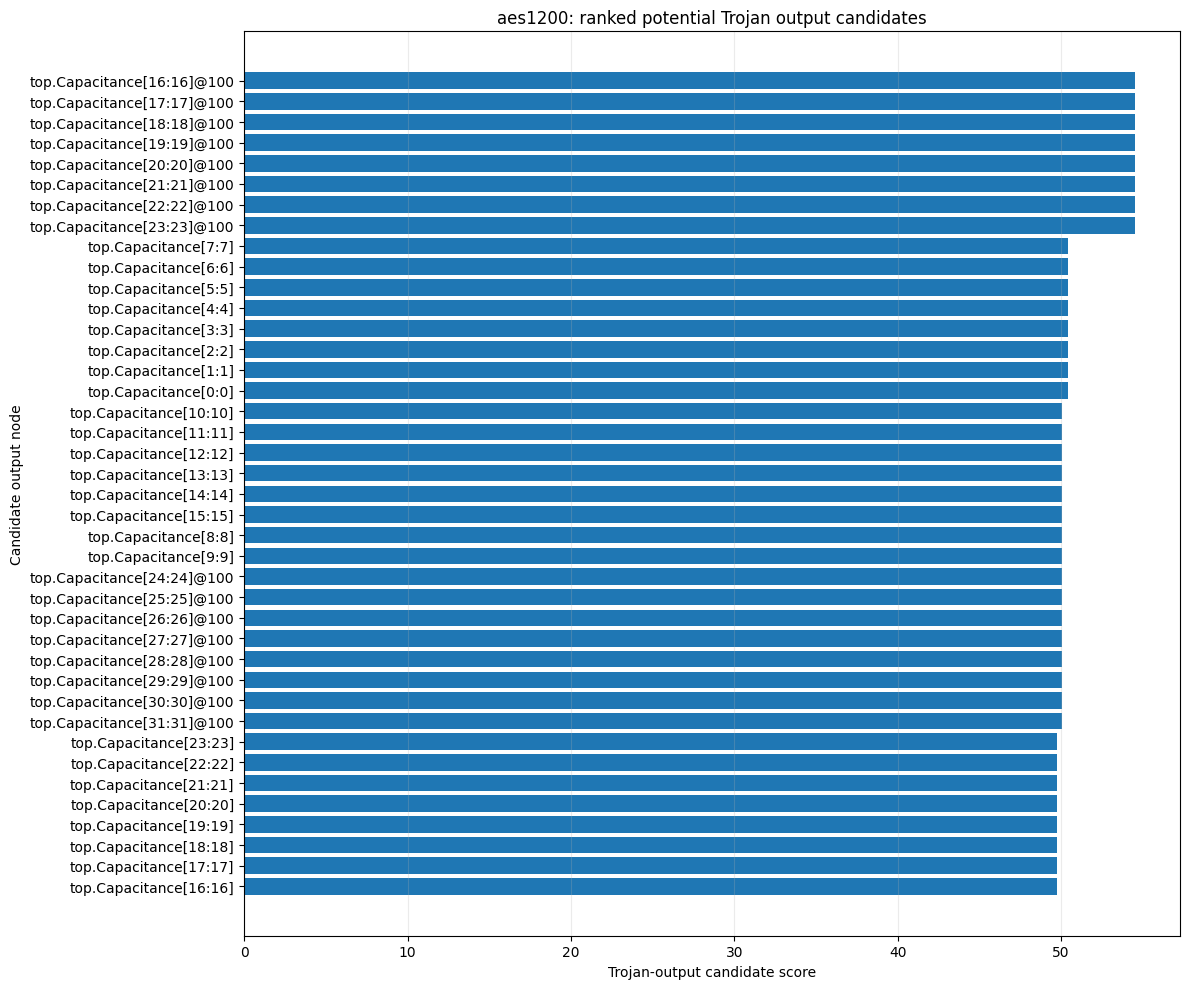

aes1200: top potential Trojan outputs
aes1600: scoring 200 output-like candidate nodes


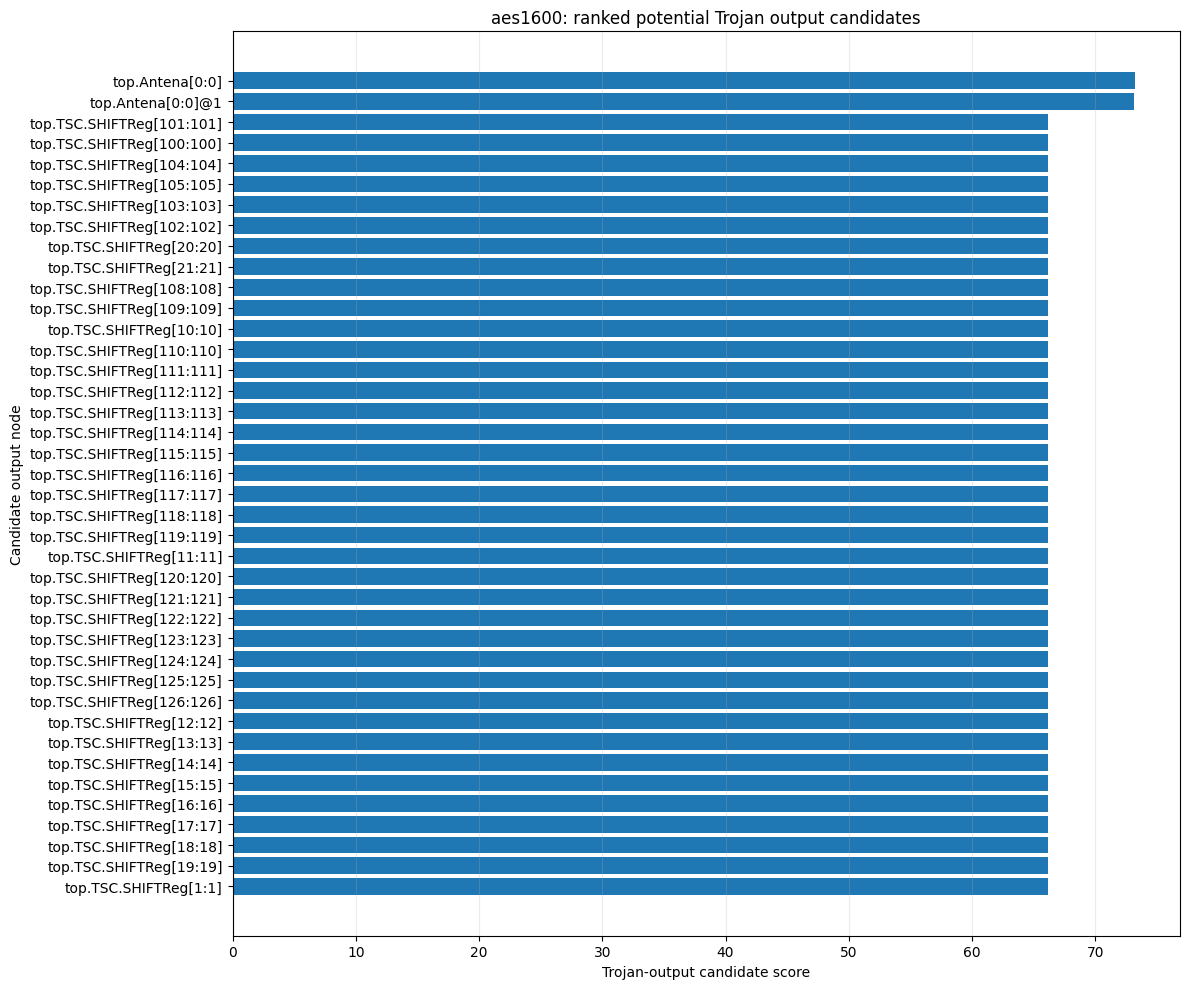

aes1600: top potential Trojan outputs
aes1700: scoring 200 output-like candidate nodes


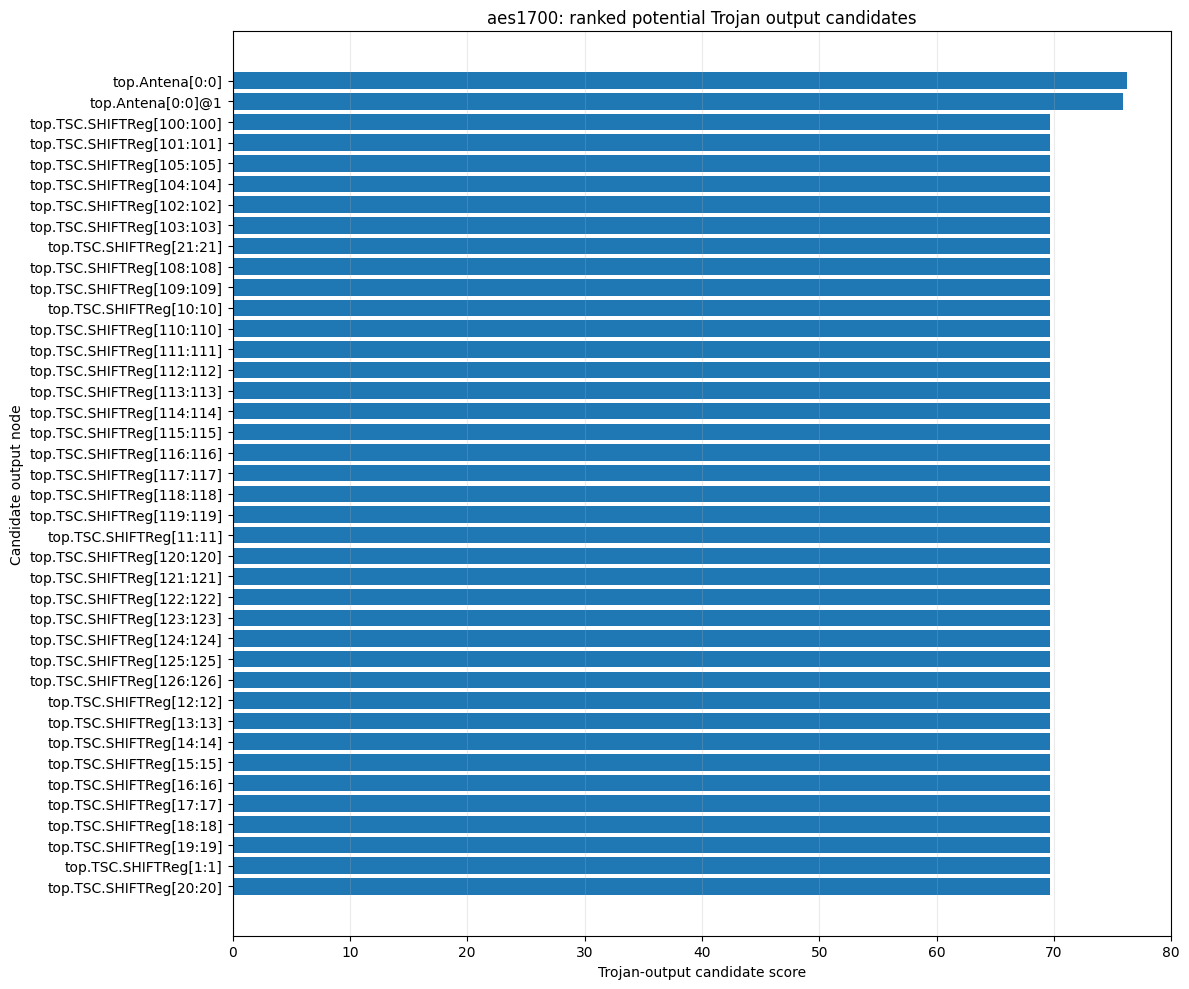

aes1700: top potential Trojan outputs
Saved combined candidate table to: fortify/analysis_outputs/leakage_topology/combined_trojan_output_candidates.csv


,combined_rank,design,candidate_output,trojan_candidate_score,leakage,best_ref,output_robust_z,output_same_level_percentile,fanin_auc_vs_rest,fanin_median_same_level_percentile,fanin_same_level_top5_frac,near_to_far_log10_lift,reason
0,1,aes1700,top.Antena[0:0],76.197739,0.000020,top.key[0:0],2.944964e+04,0.957895,0.901892,0.786432,0.019608,-4.992846,output robust-z >= 3; output top 5% at same level; fanin distribution shifted high; fanin nodes high relative to same-level nodes
1,2,aes1700,top.Antena[0:0]@1,75.903537,0.000020,top.key[0:0],2.944964e+04,0.926985,0.971977,0.786432,0.000000,-4.691816,output robust-z >= 3; fanin distribution shifted high; fanin nodes high relative to same-level nodes
2,3,aes1600,top.Antena[0:0],73.209123,0.000020,top.key[0:0],2.108240e+04,0.872920,0.870340,0.786789,0.006211,-4.992846,output robust-z >= 3; fanin distribution shifted high; fanin nodes high relative to same-level nodes
3,4,aes1600,top.Antena[0:0]@1,73.128803,0.000020,top.key[0:0],2.108240e+04,0.927297,0.923383,0.786789,0.000000,-4.691816,output robust-z >= 3; fanin distribution shifted high; fanin nodes high relative to same-level nodes
4,5,aes1700,top.TSC.SHIFTReg[100:100],69.653505,0.007812,top.key[0:0],1.131608e+07,0.392381,0.998625,0.786432,0.000000,NaN,output robust-z >= 3; fanin distribution shifted high; fanin nodes high relative to same-level nodes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,aes1700,top.TSC.SHIFTReg[6:6],69.653505,0.007812,top.key[0:0],1.131608e+07,0.392381,0.998625,0.786432,0.000000,NaN,output robust-z >= 3; fanin distribution shifted high; fanin nodes high relative to same-level nodes
96,97,aes1700,top.TSC.SHIFTReg[70:70],69.653505,0.007812,top.key[0:0],1.131608e+07,0.392381,0.998625,0.786432,0.000000,NaN,output robust-z >= 3; fanin distribution shifted high; fanin nodes high relative to same-level nodes
97,98,aes1700,top.TSC.SHIFTReg[71:71],69.653505,0.007812,top.key[0:0],1.131608e+07,0.392381,0.998625,0.786432,0.000000,NaN,output robust-z >= 3; fanin distribution shifted high; fanin nodes high relative to same-level nodes
98,99,aes1700,top.TSC.SHIFTReg[72:72],69.653505,0.007812,top.key[0:0],1.131608e+07,0.392381,0.998625,0.786432,0.000000,NaN,output robust-z >= 3; fanin distribution shifted high; fanin nodes high relative to same-level nodes


In [20]:

# -----------------------------
# Trojan-output candidate mining
# -----------------------------


def clip01(x):
    if x is None or pd.isna(x):
        return 0.0
    return float(max(0.0, min(1.0, x)))


def robust_z_scores(values):
    """Median/MAD robust z-score. Returns a Series aligned with values."""
    s = pd.to_numeric(pd.Series(values), errors="coerce")
    med = s.median()
    mad = (s - med).abs().median()
    if pd.isna(mad) or mad <= 0:
        std = s.std(ddof=0)
        denom = std if std and std > 0 else 1.0
    else:
        denom = 1.4826 * mad
    return (s - med) / denom


def rank_auc_probability_greater(a, b):
    """
    Threshold-free effect size.
    Returns P(random value from a > random value from b), with ties counted as 0.5.
    0.5 means the two distributions are similar.
    """
    a = pd.to_numeric(pd.Series(a), errors="coerce").dropna()
    b = pd.to_numeric(pd.Series(b), errors="coerce").dropna()
    n = len(a)
    m = len(b)
    if n == 0 or m == 0:
        return math.nan

    combined = pd.concat([a, b], ignore_index=True)
    ranks = combined.rank(method="average")
    rank_sum_a = ranks.iloc[:n].sum()
    u = rank_sum_a - n * (n + 1) / 2.0
    return float(u / (n * m))

INPUT_LIKE_CANDIDATE_RE = re.compile(
    r"(^|\.)in(?:\[\d+(?::\d+)?\])?$"
)


def is_input_like_candidate_node(node):
    """
    Return True for nodes ending as:
        .in
        .in[3]
        .in[3:3]
        .in[7:0]

    Time suffixes such as @0, @1 are ignored before matching.
    """
    if not isinstance(node, str):
        return False

    node_no_time = node.split("@", 1)[0]

    return bool(INPUT_LIKE_CANDIDATE_RE.search(node_no_time))

def ensure_candidate_features(bundle):
    """
    Add global leakage percentile, same-level percentile, and output robust-z features
    to bundle['node_df']. This modifies and returns the dataframe.
    """
    df = bundle["node_df"].copy()
    G = bundle["graph"]

    df["leakage"] = pd.to_numeric(df["leakage"], errors="coerce")
    leak_mask = df["has_leakage"] == True

    df["leakage_percentile_global"] = math.nan
    if leak_mask.any():
        df.loc[leak_mask, "leakage_percentile_global"] = df.loc[leak_mask, "leakage"].rank(pct=True, method="average")

    df["leakage_percentile_same_level"] = math.nan
    if leak_mask.any():
        df.loc[leak_mask, "leakage_percentile_same_level"] = (
            df.loc[leak_mask]
              .groupby("topological_level")["leakage"]
              .rank(pct=True, method="average")
        )

    # Output-like mask used only for output candidate statistics.
    prefix_mask = df["node"].map(lambda n: node_matches_prefix(n, TROJAN_OUTPUT_PREFIXES))
    sink_mask = df["node"].map(lambda n: G.out_degree(n) == 0 if n in G else False)
    input_like_mask = df["node"].map(is_input_like_candidate_node)

    if TROJAN_OUTPUT_NODE_MODE == "prefix":
        output_mask = prefix_mask
    elif TROJAN_OUTPUT_NODE_MODE == "sinks":
        output_mask = sink_mask
    elif TROJAN_OUTPUT_NODE_MODE == "prefix_or_sinks":
        output_mask = prefix_mask | sink_mask
    else:
        raise ValueError("TROJAN_OUTPUT_NODE_MODE must be 'prefix', 'sinks', or 'prefix_or_sinks'")

    output_mask = output_mask & leak_mask

    if EXCLUDE_INPUT_LIKE_CANDIDATES:
        output_mask = output_mask & ~input_like_mask

    df["is_input_like_candidate"] = input_like_mask
    df["is_output_candidate"] = output_mask
    df["output_leakage_percentile"] = math.nan
    df["output_robust_z"] = math.nan

    if output_mask.any():
        df.loc[output_mask, "output_leakage_percentile"] = df.loc[output_mask, "leakage"].rank(pct=True, method="average")
        z = robust_z_scores(df.loc[output_mask, "leakage"])
        df.loc[output_mask, "output_robust_z"] = z.to_numpy()

    bundle["node_df"] = df
    return df


def fanin_artifact_for_target(G, target):
    """
    Compute fanin cone of one target using reverse BFS over raw graph edges.
    Returns cone_nodes, cone_edges, and distance_to_target.
    """
    cone_nodes = {target}
    cone_edges = set()
    distance = {target: 0}
    q = deque([target])

    while q:
        child = q.popleft()
        child_dist = distance[child]
        for parent in G.predecessors(child):
            cone_edges.add((parent, child))
            if parent not in cone_nodes:
                cone_nodes.add(parent)
                distance[parent] = child_dist + 1
                q.append(parent)

    return cone_nodes, cone_edges, distance


def get_cached_fanin_for_target(bundle, target):
    cache = bundle.setdefault("trojan_fanin_cache", {})
    if target not in cache:
        cache[target] = fanin_artifact_for_target(bundle["graph"], target)
    return cache[target]


def _median_level_lift(cone_df, rest_df):
    """
    Median log10 lift of cone median leakage over rest median leakage at matching levels.
    Positive means the fanin cone is higher than the rest at the same levels.
    """
    if cone_df.empty or rest_df.empty:
        return math.nan

    cone_med = cone_df.groupby("topological_level")["leakage"].median()
    rest_med = rest_df.groupby("topological_level")["leakage"].median()
    common = sorted(set(cone_med.index) & set(rest_med.index))
    if not common:
        return math.nan

    vals = []
    for lvl in common:
        vals.append(math.log10((float(cone_med.loc[lvl]) + LEAKAGE_EPS) / (float(rest_med.loc[lvl]) + LEAKAGE_EPS)))
    return float(pd.Series(vals).median()) if vals else math.nan


def _distance_leakage_shape(cone_df, distance_map):
    """
    Measure how leakage changes as we move away from the target.
    distance=0 is the candidate output itself.
    Negative Spearman correlation means leakage tends to be higher near the output.
    """
    if cone_df.empty:
        return {
            "distance_spearman_corr": math.nan,
            "distance_rise_toward_target": math.nan,
            "near_to_far_log10_lift": math.nan,
        }

    tmp = cone_df.copy()
    tmp["distance_to_target"] = tmp["node"].map(distance_map)
    tmp = tmp.dropna(subset=["distance_to_target", "leakage"])
    if tmp.empty:
        return {
            "distance_spearman_corr": math.nan,
            "distance_rise_toward_target": math.nan,
            "near_to_far_log10_lift": math.nan,
        }

    prof = tmp.groupby("distance_to_target")["leakage"].median().reset_index()
    if len(prof) >= 2:
        corr = prof["distance_to_target"].corr(prof["leakage"], method="spearman")
    else:
        corr = math.nan

    near = tmp[tmp["distance_to_target"] <= TROJAN_NEAR_TARGET_DISTANCE]["leakage"]
    far = tmp[tmp["distance_to_target"] > TROJAN_NEAR_TARGET_DISTANCE]["leakage"]
    if len(near) and len(far):
        near_to_far = math.log10((float(near.median()) + LEAKAGE_EPS) / (float(far.median()) + LEAKAGE_EPS))
    else:
        near_to_far = math.nan

    return {
        "distance_spearman_corr": float(corr) if not pd.isna(corr) else math.nan,
        "distance_rise_toward_target": max(0.0, -float(corr)) if not pd.isna(corr) else math.nan,
        "near_to_far_log10_lift": near_to_far,
    }


def reason_string(row):
    reasons = []
    if row.get("output_robust_z", 0) >= 3:
        reasons.append("output robust-z >= 3")
    if row.get("output_same_level_percentile", 0) >= 0.95:
        reasons.append("output top 5% at same level")
    if row.get("fanin_auc_vs_rest", 0) >= 0.70:
        reasons.append("fanin distribution shifted high")
    if row.get("fanin_median_same_level_percentile", 0) >= 0.75:
        reasons.append("fanin nodes high relative to same-level nodes")
    if row.get("fanin_same_level_top5_frac", 0) >= 0.20:
        reasons.append("many fanin nodes top 5% at same level")
    if row.get("near_to_far_log10_lift", 0) >= 0.5:
        reasons.append("leakage higher near output")
    return "; ".join(reasons) if reasons else "ranked by combined weak signals"


def score_candidate_output(bundle, target):
    G = bundle["graph"]
    df = bundle["node_df"]
    leak_df = df[df["has_leakage"] == True].copy()

    target_rows = df[df["node"] == target]
    if target_rows.empty:
        return None
    target_row = target_rows.iloc[0]

    cone_nodes, cone_edges, distance_map = get_cached_fanin_for_target(bundle, target)
    cone_df = leak_df[leak_df["node"].isin(cone_nodes)].copy()
    rest_df = leak_df[~leak_df["node"].isin(cone_nodes)].copy()

    shape = _distance_leakage_shape(cone_df, distance_map)
    auc = rank_auc_probability_greater(cone_df["leakage"], rest_df["leakage"])
    level_lift = _median_level_lift(cone_df, rest_df)

    fanin_median_same_level = float(cone_df["leakage_percentile_same_level"].median()) if len(cone_df) else math.nan
    fanin_top5_frac = float((cone_df["leakage_percentile_same_level"] >= 0.95).mean()) if len(cone_df) else math.nan
    fanin_top1_frac = float((cone_df["leakage_percentile_same_level"] >= 0.99).mean()) if len(cone_df) else math.nan
    fanin_global_top5_frac = float((cone_df["leakage_percentile_global"] >= 0.95).mean()) if len(cone_df) else math.nan

    # Turn raw statistics into 0..1 evidence components.
    output_pct_component = clip01(target_row.get("output_leakage_percentile", math.nan))
    output_same_level_component = clip01(target_row.get("leakage_percentile_same_level", math.nan))
    output_z_component = clip01(float(target_row.get("output_robust_z", 0.0)) / 6.0)
    auc_component = clip01((auc - 0.5) / 0.5) if not pd.isna(auc) else 0.0
    fanin_same_level_component = clip01(fanin_median_same_level)
    fanin_top5_component = clip01(fanin_top5_frac / 0.25) if not pd.isna(fanin_top5_frac) else 0.0
    distance_component = clip01(shape["distance_rise_toward_target"]) if not pd.isna(shape["distance_rise_toward_target"]) else 0.0

    # Penalize almost-empty cones because they are less informative as Trojan paths.
    cone_size_component = clip01(len(cone_df) / max(TROJAN_MIN_FANIN_LEAKAGE_NODES, 1))

    score_0_1 = cone_size_component * (
        0.18 * output_pct_component
        + 0.17 * output_same_level_component
        + 0.15 * output_z_component
        + 0.20 * auc_component
        + 0.15 * fanin_same_level_component
        + 0.10 * fanin_top5_component
        + 0.05 * distance_component
    )

    row = {
        "design": bundle["design"],
        "candidate_output": target,
        "trojan_candidate_score": 100.0 * score_0_1,
        "leakage": float(target_row.get("leakage", math.nan)),
        "best_ref": target_row.get("best_ref", ""),
        "topological_level": int(target_row.get("topological_level", -1)),
        "indegree": int(G.in_degree(target)) if target in G else 0,
        "outdegree": int(G.out_degree(target)) if target in G else 0,
        "output_leakage_percentile": float(target_row.get("output_leakage_percentile", math.nan)),
        "output_same_level_percentile": float(target_row.get("leakage_percentile_same_level", math.nan)),
        "output_global_percentile": float(target_row.get("leakage_percentile_global", math.nan)),
        "output_robust_z": float(target_row.get("output_robust_z", math.nan)),
        "fanin_nodes_total": len(cone_nodes),
        "fanin_edges_total": len(cone_edges),
        "fanin_leakage_nodes": len(cone_df),
        "rest_leakage_nodes": len(rest_df),
        "fanin_auc_vs_rest": auc,
        "fanin_median_leakage": float(cone_df["leakage"].median()) if len(cone_df) else math.nan,
        "rest_median_leakage": float(rest_df["leakage"].median()) if len(rest_df) else math.nan,
        "fanin_p90_leakage": float(cone_df["leakage"].quantile(0.90)) if len(cone_df) else math.nan,
        "rest_p90_leakage": float(rest_df["leakage"].quantile(0.90)) if len(rest_df) else math.nan,
        "fanin_median_same_level_percentile": fanin_median_same_level,
        "fanin_same_level_top5_frac": fanin_top5_frac,
        "fanin_same_level_top1_frac": fanin_top1_frac,
        "fanin_global_top5_frac": fanin_global_top5_frac,
        "median_level_log10_lift_cone_over_rest": level_lift,
        "max_distance_to_target": max(distance_map.values()) if distance_map else 0,
        **shape,
    }
    row["reason"] = reason_string(row)
    return row


def select_candidate_outputs_for_scoring(bundle):
    df = ensure_candidate_features(bundle)
    cand = df[df["is_output_candidate"] == True].copy()

    if EXCLUDE_INPUT_LIKE_CANDIDATES:
        cand = cand[
            ~cand["node"].map(is_input_like_candidate_node)
        ].copy()

    cand = cand.sort_values(["output_leakage_percentile", "leakage"], ascending=False)
    
    if TROJAN_MAX_OUTPUT_CANDIDATES_TO_SCORE is not None:
        cand = cand.head(int(TROJAN_MAX_OUTPUT_CANDIDATES_TO_SCORE))

    return cand["node"].tolist(), cand


def score_trojan_outputs_for_design(bundle):
    design = bundle["design"]
    out_dir = bundle["out_dir"]

    candidates, candidate_base_df = select_candidate_outputs_for_scoring(bundle)
    print(f"{design}: scoring {len(candidates)} output-like candidate nodes")

    rows = []
    for target in candidates:
        row = score_candidate_output(bundle, target)
        if row is not None:
            rows.append(row)

    score_df = pd.DataFrame(rows)
    if score_df.empty:
        print(f"{design}: no candidate outputs scored")
        return score_df

    score_df = score_df.sort_values("trojan_candidate_score", ascending=False).reset_index(drop=True)
    score_df.insert(0, "rank", range(1, len(score_df) + 1))

    # Save enhanced node table and candidate results.
    bundle["node_df"].to_csv(out_dir / f"{design}_nodes_levels_leakage_candidate_features.csv", index=False)
    score_df.to_csv(out_dir / f"{design}_trojan_output_candidates.csv", index=False)

    # Save the per-target fanin cache for later reuse.
    with open(out_dir / f"{design}_trojan_fanin_cache.pkl", "wb") as f:
        pickle.dump(bundle.get("trojan_fanin_cache", {}), f)

    # Plot top candidates.
    top = score_df.head(TROJAN_BAR_PLOT_TOP_N).copy()
    fig, ax = plt.subplots(figsize=(12, max(5, 0.25 * len(top))))
    ax.barh(top["candidate_output"][::-1], top["trojan_candidate_score"][::-1])
    ax.set_xlabel("Trojan-output candidate score")
    ax.set_ylabel("Candidate output node")
    ax.set_title(f"{design}: ranked potential Trojan output candidates")
    ax.grid(True, axis="x", alpha=0.25)
    fig.tight_layout()
    path = out_dir / f"{design}_trojan_output_candidate_scores.png"
    if SAVE_PLOTS:
        fig.savefig(path, dpi=220)
    if SHOW_PLOTS_IN_NOTEBOOK:
        display(fig)
    plt.close(fig)

    display_cols = [
        "rank", "candidate_output", "trojan_candidate_score", "leakage", "best_ref",
        "output_robust_z", "output_same_level_percentile", "fanin_auc_vs_rest",
        "fanin_median_same_level_percentile", "fanin_same_level_top5_frac",
        "near_to_far_log10_lift", "reason",
    ]
    print(f"{design}: top potential Trojan outputs")
    # display(score_df[display_cols].head(TROJAN_TOP_REPORT_N))

    bundle["trojan_candidates_df"] = score_df
    return score_df


def run_trojan_candidate_mining(bundles=None):
    if bundles is None:
        if "all_bundles" in globals() and all_bundles:
            bundles = all_bundles
        elif "one_bundle" in globals():
            bundles = [one_bundle]
        else:
            raise RuntimeError("Run analyze_design(...) first so one_bundle or all_bundles exists.")

    all_scores = []
    for bundle in bundles:
        score_df = score_trojan_outputs_for_design(bundle)
        if not score_df.empty:
            all_scores.append(score_df)

    if not all_scores:
        print("No Trojan-output candidates were found.")
        return pd.DataFrame()

    combined = pd.concat(all_scores, ignore_index=True)
    combined = combined.sort_values(["trojan_candidate_score", "leakage"], ascending=False).reset_index(drop=True)
    combined.insert(0, "combined_rank", range(1, len(combined) + 1))

    combined_path = OUTPUT_ROOT / "combined_trojan_output_candidates.csv"
    combined.to_csv(combined_path, index=False)

    print(f"Saved combined candidate table to: {combined_path}")
    display_cols = [
        "combined_rank", "design", "candidate_output", "trojan_candidate_score", "leakage", "best_ref",
        "output_robust_z", "output_same_level_percentile", "fanin_auc_vs_rest",
        "fanin_median_same_level_percentile", "fanin_same_level_top5_frac",
        "near_to_far_log10_lift", "reason",
    ]
    display(combined[display_cols].head(TROJAN_TOP_REPORT_N))

    return combined


# Run this after one_bundle or all_bundles exists.
trojan_candidates_df = run_trojan_candidate_mining()
